In [1]:
import numpy as np
import pandas as pd
import os
import sys
import pandas as pd
from scipy.stats import gaussian_kde

## Task 0 - Load data

In [2]:
crops = pd.read_csv('data/FAOSTAT_crops.csv')
df_faostat_prices = pd.read_csv("data/FAOSTAT_prices.csv")

In [3]:
def crops_format(df, name):
    df = crops[crops['Item'] == name]
    df = df[['Area', 'Unit', 'Element', 'Item', 'Year', 'Value']]
    df_ = pd.pivot_table(df, index=['Item', 'Year'], columns='Element', values='Value').reset_index()
    df_ = df_.rename(columns={'Year': 'date'})
    df_ = df_[['Item', 'date', 'Area harvested', 'Yield', 'Production']]
    return df_

grapes = crops_format(crops, "Grapes")
print(grapes.head(10))
wheat = crops_format(crops, "Wheat")
print(wheat.head(10))
maize = crops_format(crops, "Maize (corn)")
print(maize.head(10))
sunflower = crops_format(crops, "Sunflower seed")
print(sunflower.head(10))

Element    Item  date  Area harvested   Yield  Production
0        Grapes  1980       1657400.0  4055.4   6721400.0
1        Grapes  1981       1657000.0  3260.4   5402503.0
2        Grapes  1982       1658000.0  3635.7   6028000.0
3        Grapes  1983       1645330.0  3111.3   5119100.0
4        Grapes  1984       1587250.0  3548.4   5632200.0
5        Grapes  1985       1552387.0  3510.9   5450240.0
6        Grapes  1986       1531200.0  3828.7   5862500.0
7        Grapes  1987       1514000.0  4204.0   6364800.0
8        Grapes  1988       1439900.0  2611.6   3760400.0
9        Grapes  1989       1434900.0  3508.0   5033600.0
Element   Item  date  Area harvested   Yield  Production
0        Wheat  1980       2698700.0  2237.9   6039500.0
1        Wheat  1981       2635400.0  1293.4   3408500.0
2        Wheat  1982       2662000.0  1656.8   4410300.0
3        Wheat  1983       2603600.0  1639.2   4267900.0
4        Wheat  1984       2305700.0  2624.9   6052300.0
5        Wheat  1985

Unités de mesure :
- Yield (in kg/ha)
- Production (in t)
- Area harvested (in ha)



Répartition de la ferme :

- total = 70 ha
- 10% tomatoes
- 20% sunflower
- 30% maize
- 10% grapes
- 30% wheat

In [4]:
SPI = pd.read_csv('data/SPI.csv')

SPI['time'] = pd.to_datetime(SPI['time'])

SPI = SPI.rename(columns={'SPI3': 'SPI'})

SPI['year'] = SPI['time'].dt.year
SPI_index = SPI.groupby('year')['SPI'].mean().reset_index()
SPI_index = SPI_index.rename(columns={'year': 'date'})

# Formater la date avec l'année-mois-jour heure (01-01 00:00:00)
SPI_index['date'] = pd.to_datetime(SPI_index['date'].astype(str))
print(SPI_index.tail(10))

         date       SPI
36 2016-01-01  0.917828
37 2017-01-01 -0.337647
38 2018-01-01  0.835146
39 2019-01-01 -0.848611
40 2020-01-01  0.568367
41 2021-01-01 -0.225714
42 2022-01-01 -0.389805
43 2023-01-01 -0.141447
44 2024-01-01  0.009841
45 2025-01-01  1.844582


In [5]:
df_faostat_prices = df_faostat_prices.loc[:,["Item Code (CPC)", "Item", "Year", "Unit", "Value"]]
df_faostat_prices.rename(columns={"Year": "date"}, inplace=True)

In [6]:
grapes_prices = df_faostat_prices[df_faostat_prices["Item"] == "Grapes"].drop(columns=["Item Code (CPC)"])
maize_prices = df_faostat_prices[df_faostat_prices["Item"] == "Maize (corn)"].drop(columns=["Item Code (CPC)"])
sunflower_prices = df_faostat_prices[df_faostat_prices["Item"] == "Sunflower seed"].drop(columns=["Item Code (CPC)"])
wheat_prices = df_faostat_prices[df_faostat_prices["Item"] == "Wheat"].drop(columns=["Item Code (CPC)"])


In [7]:
def merge_price(df, price_df):
    df = pd.merge(df, price_df[['date', 'Value']], on='date', how='left')
    df = df.rename(columns={'Value': 'Price'})
    df.dropna(inplace=True)
    return df

grapes = merge_price(grapes, grapes_prices)
wheat = merge_price(wheat, wheat_prices)
maize = merge_price(maize, maize_prices)
sunflower = merge_price(sunflower, sunflower_prices)

In [8]:
ipampa_overall_index = pd.read_csv("data/IPAMPA_overall_index.csv", sep=";")
ipampa_overall_index.rename(columns={"Label": "date", "Annual agricultural means of production purchasing price index (IPAMPA) - Overall index": "IPAMPA_overall_index"}, inplace=True)
print(ipampa_overall_index.head(10))

   date  IPAMPA_overall_index
0  2025                 124.7
1  2024                 125.4
2  2023                 131.2
3  2022                 133.7
4  2021                 109.2
5  2020                 100.0
6  2019                 101.7
7  2018                 100.2
8  2017                  96.7
9  2016                  95.5


## Task 1
#### Calul des revenus (outputs)


In [9]:
weights = {"Grapes": 0.2, "Maize (corn)": 0.3, "Sunflower seed": 0.2, "Wheat": 0.3}
total = 20 #ha
ha_grapes = total * weights["Grapes"]
ha_maize = total * weights["Maize (corn)"]
ha_sunflower = total * weights["Sunflower seed"]
ha_wheat = total * weights["Wheat"]

In [10]:
grapes["Yield_tot"] = grapes["Yield"] * ha_grapes * 0.001 #en tonnes
maize["Yield_tot"] = maize["Yield"] * ha_maize * 0.001 #en tonnes
sunflower["Yield_tot"] = sunflower["Yield"] * ha_sunflower * 0.001 #en tonnes
wheat["Yield_tot"] = wheat["Yield"] * ha_wheat * 0.001 #en tonnes
print(grapes.tail(10))

      Item  date  Area harvested   Yield  Production   Price  Yield_tot
35  Grapes  2015        941056.0  6162.4   5799131.0   778.2    24.6496
36  Grapes  2016        935105.0  6526.4   6102851.0   756.3    26.1056
37  Grapes  2017        937763.0  5745.0   5387403.0   937.5    22.9800
38  Grapes  2018        939920.0  7429.6   6983260.0   861.5    29.7184
39  Grapes  2019        936890.0  6132.5   5745450.0   774.0    24.5300
40  Grapes  2020        931630.0  7318.1   6817770.0   795.0    29.2724
41  Grapes  2021        929390.0  6549.4   6086920.0   956.2    26.1976
42  Grapes  2022        922920.0  6395.0   5902040.0   798.3    25.5800
43  Grapes  2023        913000.0  5282.3   4822760.0   978.5    21.1292
44  Grapes  2024        903980.0  5959.5   5387270.0  1003.9    23.8380


In [11]:
grapes["Revenue"] = grapes["Yield_tot"] * grapes["Price"]
wheat["Revenue"] = wheat["Yield_tot"] * wheat["Price"]
maize["Revenue"] = maize["Yield_tot"] * maize["Price"]
sunflower["Revenue"] = sunflower["Yield_tot"] * sunflower["Price"]


In [12]:
flows= pd.concat([grapes[['date', 'Revenue']], wheat[['date', 'Revenue']], maize[['date', 'Revenue']], sunflower[['date', 'Revenue']]])
flows = flows.groupby('date')['Revenue'].sum().reset_index()
print(flows.tail(10))


    date      Revenue
24  2015  37992.56076
25  2016  38021.02596
26  2017  39370.44852
27  2018  47770.80932
28  2019  38552.46798
29  2020  47411.77770
30  2021  59135.49556
31  2022  53223.24834
32  2023  45856.74676
33  2024  49040.15894


#### Calcul des coûts (inputs)

Nous allons utiliser un indice de prix de coûts calculé par l'INSEE : IPAMPA
Cet indice est en base 100 = 2020

Prix en 2020:
- Fertilisation (Azote, P, K) = 175 € (35.35 %)
- Phytosanitaires = 45 € (9.09 %)
- Semences = 70 € (14.14 %)
- Carburant (GNR) = 65 € (13.13 %)
- Séchage / Divers = 45 € (9.09 %)
- Main d'oeuvre = 95 € (19.19 %)

Total = 595 euros = 0.88 * 595 \$ = 523.6 \$ de coûts en 2020


In [13]:
#ipampa_overall_index["Cost"] = 523.6 * 20 * 100 / ipampa_overall_index["IPAMPA_overall_index"]
ipampa_overall_index["Cost"] = 523.6 * 20 * ipampa_overall_index["IPAMPA_overall_index"] /100
print(ipampa_overall_index)

    date  IPAMPA_overall_index       Cost
0   2025                 124.7  13058.584
1   2024                 125.4  13131.888
2   2023                 131.2  13739.264
3   2022                 133.7  14001.064
4   2021                 109.2  11435.424
5   2020                 100.0  10472.000
6   2019                 101.7  10650.024
7   2018                 100.2  10492.944
8   2017                  96.7  10126.424
9   2016                  95.5  10000.760
10  2015                  98.0  10262.560
11  2014                 100.3  10503.416
12  2013                 102.8  10765.216
13  2012                 101.8  10660.496
14  2011                  98.8  10346.336
15  2010                  90.6   9487.632
16  2009                  90.1   9435.272
17  2008                  96.2  10074.064
18  2007                  84.8   8880.256
19  2006                  80.3   8409.016
20  2005                  78.1   8178.632


#### Calcul de la Marge

In [14]:
flows = pd.merge(flows, ipampa_overall_index[['date', 'Cost', 'IPAMPA_overall_index']], left_on='date', right_on='date', how='left')
flows.dropna(inplace=True)
flows['Margin'] = flows['Revenue'] - flows['Cost']
flows.rename(columns={'IPAMPA_overall_index': 'IPAMPA'}, inplace=True)
print(flows.tail(10))


    date      Revenue       Cost  IPAMPA       Margin
24  2015  37992.56076  10262.560    98.0  27730.00076
25  2016  38021.02596  10000.760    95.5  28020.26596
26  2017  39370.44852  10126.424    96.7  29244.02452
27  2018  47770.80932  10492.944   100.2  37277.86532
28  2019  38552.46798  10650.024   101.7  27902.44398
29  2020  47411.77770  10472.000   100.0  36939.77770
30  2021  59135.49556  11435.424   109.2  47700.07156
31  2022  53223.24834  14001.064   133.7  39222.18434
32  2023  45856.74676  13739.264   131.2  32117.48276
33  2024  49040.15894  13131.888   125.4  35908.27094


## Task 2

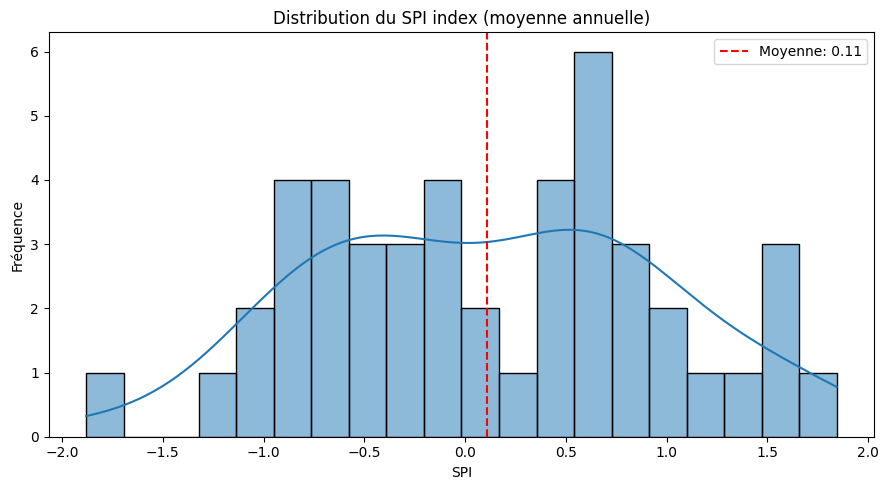

count    46.000000
mean      0.111135
std       0.856195
min      -1.880435
25%      -0.594034
50%       0.041024
75%       0.675057
max       1.844582
Name: SPI, dtype: float64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution du SPI index annuel
plt.figure(figsize=(9, 5))
sns.histplot(SPI_index['SPI'].dropna(), bins=20, kde=True)
plt.axvline(SPI_index['SPI'].mean(), color='red', linestyle='--', label=f"Moyenne: {SPI_index['SPI'].mean():.2f}")
plt.title('Distribution du SPI index (moyenne annuelle)')
plt.xlabel('SPI')
plt.ylabel('Fréquence')
plt.legend()
plt.tight_layout()
plt.show()

print(SPI_index['SPI'].describe())

On prend comme treshold -0.5 pour rester cohérent avec l'article Probabilistic estimates of drought impacts on agricultural production et puisque le premier quartile de la distribution des valeurs de l'indicateur de sécheresse est égal à -0.6, ce qui est similaire.

✔ data/spi_annuel_depuis_SPI_csv.png sauvegardé


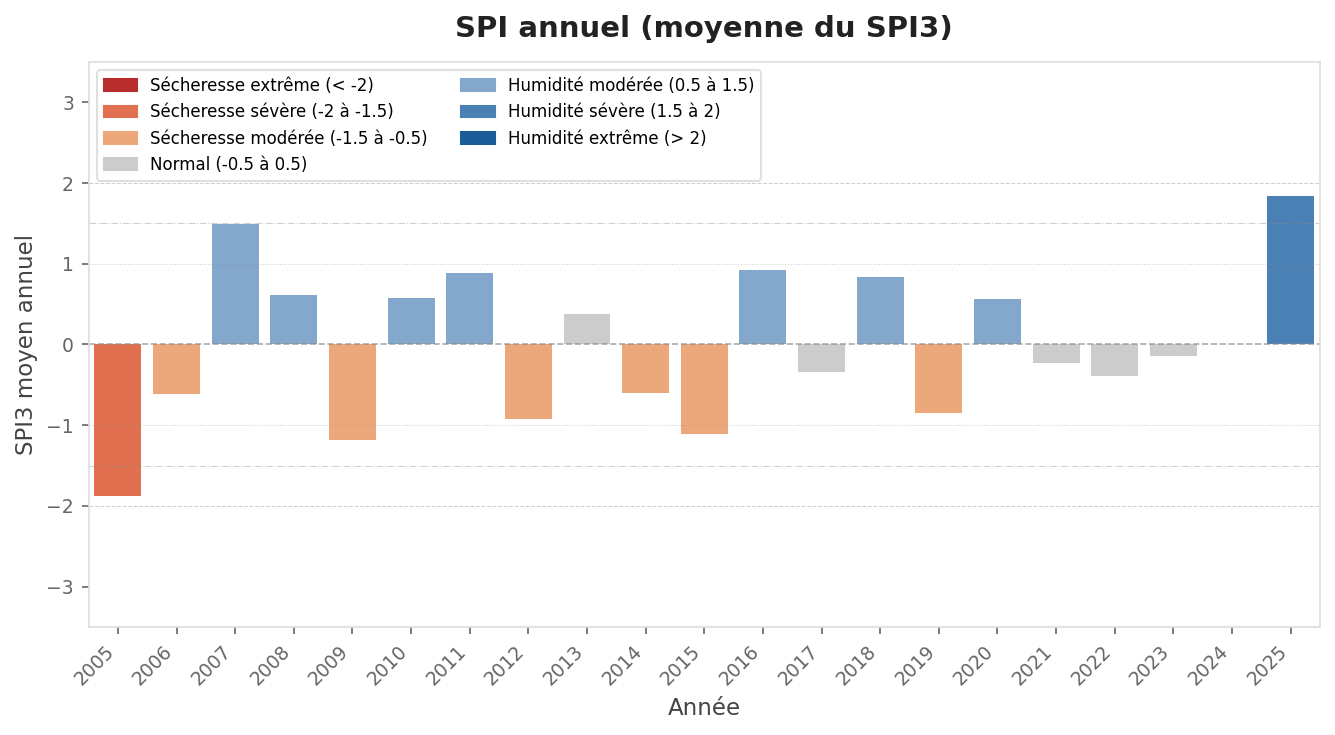


Done.
        date  spi_annuel  year
0 2005-01-01   -1.880435  2005
1 2006-01-01   -0.612123  2006
2 2007-01-01    1.496556  2007
3 2008-01-01    0.611453  2008
4 2009-01-01   -1.181186  2009


In [16]:
"""
Visualisation du SPI annuel à partir de data/SPI.csv
Le fichier contient: time, lat, lon, SPI3 (3 mois).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────
# PARAMÈTRES
# ─────────────────────────────────────────────
FICHIER_SPI = "data/SPI.csv"
DPI = 150

# Catégories SPI (OMM)
BINS = [-np.inf, -2.0, -1.5, -0.5, 0.5, 1.5, 2.0, np.inf]
COLORS = ["#B72D2D", "#E07050", "#ECA87A", "#CCCCCC", "#83A8CC", "#4A80B4", "#1B5C99"]
LABELS = [
    "Sécheresse extrême (< -2)",
    "Sécheresse sévère (-2 à -1.5)",
    "Sécheresse modérée (-1.5 à -0.5)",
    "Normal (-0.5 à 0.5)",
    "Humidité modérée (0.5 à 1.5)",
    "Humidité sévère (1.5 à 2)",
    "Humidité extrême (> 2)",
]

def couleur_spi(valeur):
    for i in range(len(BINS) - 1):
        if BINS[i] <= valeur < BINS[i + 1]:
            return COLORS[i]
    return COLORS[3]

# ─────────────────────────────────────────────
# CHARGEMENT + AGRÉGATION ANNUELLE (via colonne date)
# ─────────────────────────────────────────────
df = pd.read_csv(FICHIER_SPI)
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time", "SPI3"])
df = df[df["time"].dt.year >= 2005]

df["date"] = df["time"].dt.to_period("Y").dt.to_timestamp()

df_a = df.groupby("date", as_index=False)["SPI3"].mean()
df_a = df_a.rename(columns={"SPI3": "spi_annuel"})
df_a["year"] = df_a["date"].dt.year

# ─────────────────────────────────────────────
# FIGURE : SPI ANNUEL
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=DPI)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors_a = [couleur_spi(v) for v in df_a["spi_annuel"]]
ax.bar(df_a["year"], df_a["spi_annuel"], color=colors_a, width=0.8, linewidth=0)

# Ligne zéro + seuils
ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--", alpha=0.7)
for seuil, ls in [(-1, ":"), (-1.5, "-."), (-2, "--"), (1, ":"), (1.5, "-."), (2, "--")]:
    ax.axhline(seuil, color="#888888", linewidth=0.5, linestyle=ls, alpha=0.4)

ax.set_xlim(df_a["year"].min() - 0.5, df_a["year"].max() + 0.5)
ax.set_ylim(-3.5, 3.5)
ax.set_xticks(df_a["year"])
ax.set_xticklabels(df_a["year"], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Année", fontsize=11, color="#444")
ax.set_ylabel("SPI3 moyen annuel", fontsize=11, color="#444")
ax.set_title("SPI annuel (moyenne du SPI3)", fontsize=14, fontweight="bold", pad=12, color="#222")

ax.tick_params(colors="#666", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#dddddd")

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
ax.legend(
    handles=patches,
    loc="upper left",
    fontsize=8,
    framealpha=0.9,
    edgecolor="#dddddd",
    ncol=2,
)

plt.tight_layout()
plt.savefig("data/spi_annuel_depuis_SPI_csv.png", dpi=DPI, bbox_inches="tight")
print("✔ data/spi_annuel_depuis_SPI_csv.png sauvegardé")
plt.show()

print("\nDone.")
print(df_a.head())


The annual mean of SPI3 does not suggest a simple monotonic increase in drought exposure over time. Instead, it points to strong interannual variability, with alternating dry and wet years throughout the sample. Several years stand out as clearly dry, notably 2005 and then again around 2012–2015, which appears to be the most sustained relatively dry phase in the series. At the same time, this pattern is repeatedly interrupted by wetter years such as 2007, 2008, 2010, 2011, 2016, 2018, 2020, and especially 2025. Overall, the series suggests recurrent exposure to drought episodes rather than a continuous worsening trend. That said, because this indicator is based on the annual average of SPI3, it smooths short-term and seasonal extremes: a year with severe summer drought may still appear close to normal if wetter conditions prevail during the rest of the year. As a result, the figure is best interpreted as showing broad annual hydro-climatic fluctuations rather than the full intensity or persistence of drought conditions.

## Task 3

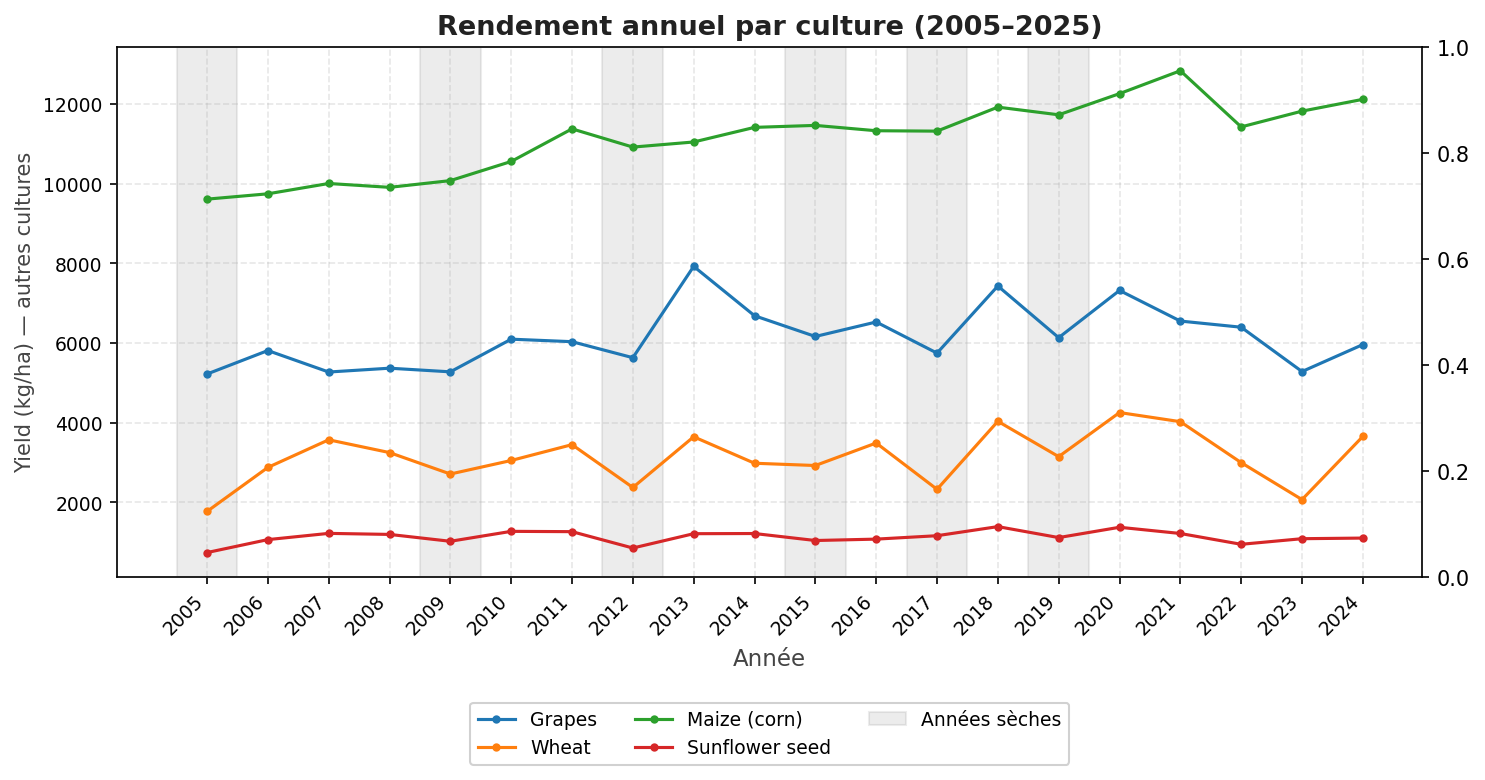

In [17]:
crops_left = {
    "Grapes": grapes,
    "Wheat": wheat,
    "Maize (corn)": maize,
    "Sunflower seed": sunflower,
}

dry_years = [2005, 2009, 2012, 2015, 2017, 2019]

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=150)
ax2 = ax1.twinx()

# Bandes grises pour années sèches (en arrière-plan)
for yr in dry_years:
    ax1.axvspan(yr - 0.5, yr + 0.5, color="gray", alpha=0.15, zorder=0)

# Cultures sur axe gauche
for name, df_crop in crops_left.items():
    df_filtered = df_crop[df_crop["date"] >= 2005].dropna(subset=["Yield"])
    ax1.plot(df_filtered["date"], df_filtered["Yield"], marker="o", markersize=3, linewidth=1.5, label=name)


# Ticks années entières
all_years = sorted(grapes[grapes["date"] >= 2005]["date"].unique())
ax1.set_xticks(all_years)
ax1.set_xticklabels(all_years, rotation=45, ha="right", fontsize=8)

# Axes
ax1.set_xlabel("Année", fontsize=11, color="#444")
ax1.set_ylabel("Yield (kg/ha) — autres cultures", fontsize=10, color="#444")

ax1.set_title("Rendement annuel par culture (2005–2025)", fontsize=13, fontweight="bold", color="#222")

# Légende combinée — placée en dehors du graphique, en bas
dry_patch = mpatches.Patch(color="gray", alpha=0.15, label="Années sèches")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + [dry_patch], labels1 + labels2 + ["Années sèches"], fontsize=9, framealpha=0.9,
           loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)

ax1.tick_params(labelsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor("#dddddd")


# Grille légère
ax1.grid(True, alpha=0.3, linestyle='--')


plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()


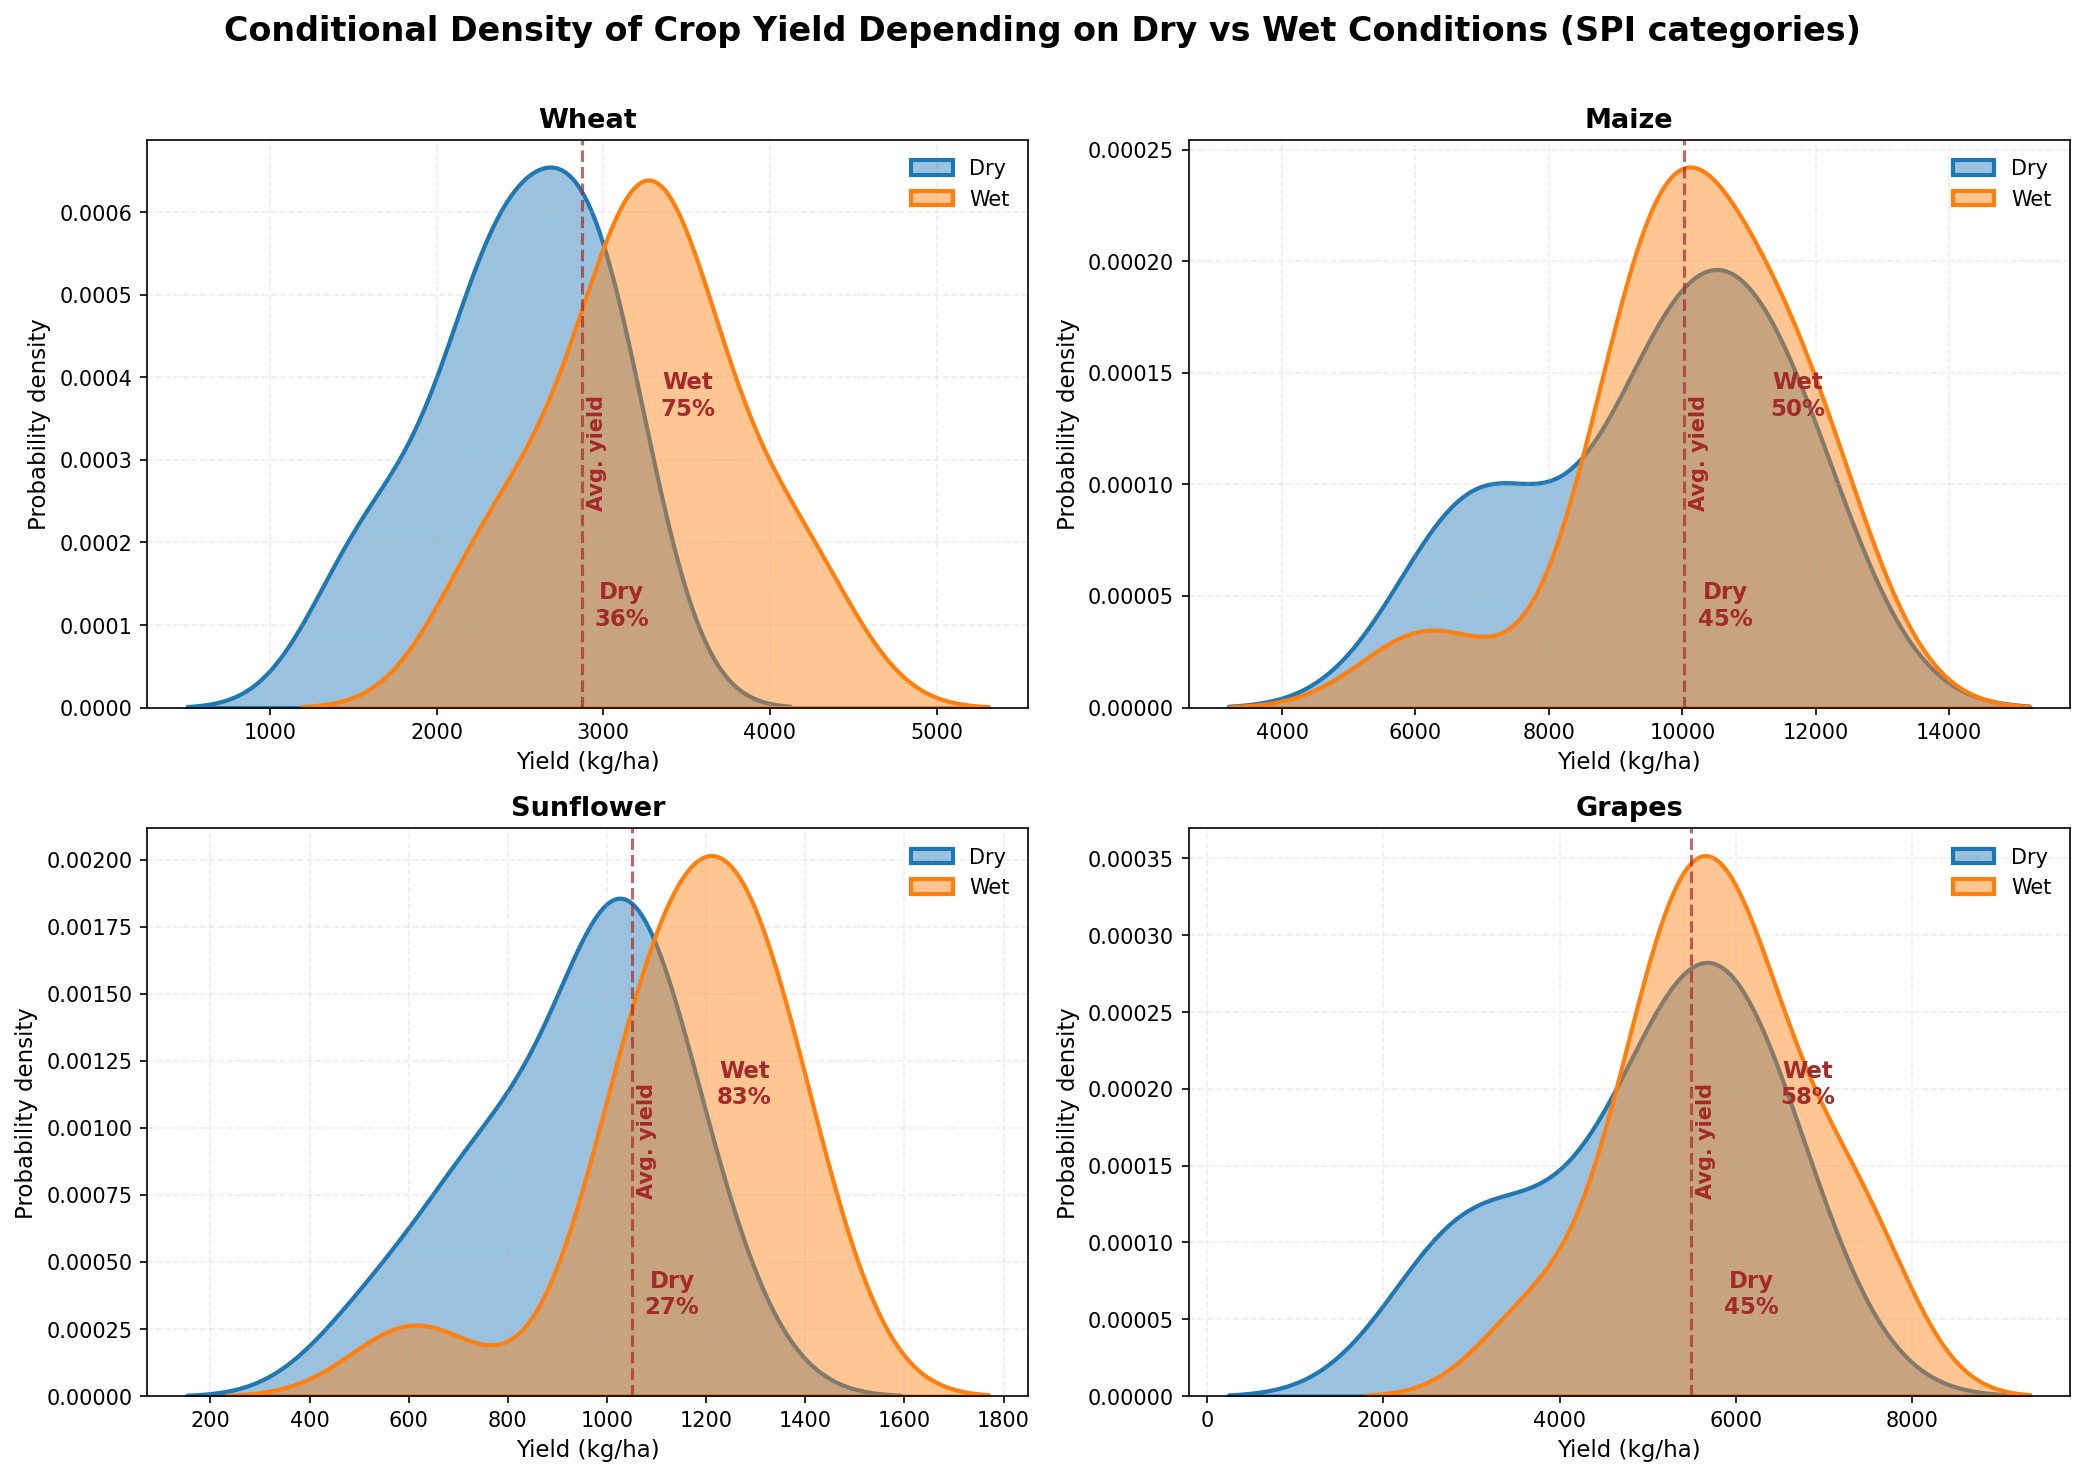

In [18]:
SPI = SPI_index.copy()
SPI['date'] = pd.to_datetime(SPI['date']).dt.year
SPI = SPI[['date', 'SPI']].dropna().groupby('date', as_index=False)['SPI'].mean()

crops = {
    'Wheat': wheat.copy(),
    'Maize': maize.copy(),
    'Sunflower': sunflower.copy(),
    'Grapes': grapes.copy()
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=150)
axes = axes.flatten()

for ax, (crop_name, df) in zip(axes, crops.items()):
    df = df.copy()
    df['date'] = df['date'].astype(int)

    df = df.drop(columns=['SPI'], errors='ignore')
    df = df.merge(SPI, on='date', how='left')

    df_dry = df[df['SPI'] < -0.5].copy()
    df_wet = df[df['SPI'] >= 0.5].copy()

    avg_yield = df['Yield'].mean()
    x_range = df['Yield'].max() - df['Yield'].min()

    x_range = df['Yield'].max() - df['Yield'].min()

    # KDE dry / wet
    sns.kdeplot(
        data=df_dry,
        x='Yield',
        label='Dry',
        fill=True,
        alpha=0.45,
        linewidth=2,
        ax=ax
    )

    sns.kdeplot(
        data=df_wet,
        x='Yield',
        label='Wet',
        fill=True,
        alpha=0.45,
        linewidth=2,
        ax=ax
    )

    # Ligne verticale moyenne
    ax.axvline(avg_yield, linestyle='--', linewidth=1.5, color='brown', alpha=0.7)


    dry_den = len(df_dry.dropna(subset=['Yield']))
    wet_den = len(df_wet.dropna(subset=['Yield']))

    dry_pct = (len(df_dry[df_dry['Yield'] > avg_yield]) / dry_den * 100) if dry_den > 0 else 0
    wet_pct = (len(df_wet[df_wet['Yield'] > avg_yield]) / wet_den * 100) if wet_den > 0 else 0


    offsets = {
        'Wheat': (650, 250),
        'Maize': (900, 1700),
        'Sunflower': (120, 70),
        'Grapes': (900, 1000)
    }

    # Texte moyenne
    ax.text(
        avg_yield + 0.01 * x_range,
        ax.get_ylim()[1] * 0.45,
        'Avg. yield',
        rotation=90,
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='brown'
    )

    # Annotations
    if len(df_dry) > 0:
        ax.text(
            df_dry['Yield'].median() + offsets[crop_name][0],
            ax.get_ylim()[1] * 0.18,
            f"Dry\n{dry_pct:.0f}%",
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='brown'
        )

    if len(df_wet) > 0:
        ax.text(
            df_wet['Yield'].median() + offsets[crop_name][1],
            ax.get_ylim()[1] * 0.55,
            f"Wet\n{wet_pct:.0f}%",
            ha='center',
            va='center',
            fontsize=11,
            fontweight='bold',
            color='brown'
        )

    ax.set_title(f'{crop_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Yield (kg/ha)', fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.grid(alpha=0.2, linestyle='--')
    ax.legend(frameon=False)

plt.suptitle('Conditional Density of Crop Yield Depending on Dry vs Wet Conditions (SPI categories)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [19]:
flows_returns = flows.copy()
flows_returns['Revenue'] = flows_returns['Revenue'].pct_change().dropna()*100
flows_returns['Cost'] = flows_returns['Cost'].pct_change().dropna()*100
flows_returns['Margin'] = flows_returns['Margin'].pct_change().dropna()*100
flows_returns['IPAMPA'] = flows_returns['IPAMPA'].pct_change().dropna()*100
flows_returns = flows_returns.dropna()
print(flows_returns.head(10))



    date    Revenue       Cost     IPAMPA     Margin
15  2006  17.340423   2.816901   2.816901  24.169351
16  2007  38.034660   5.603985   5.603985  50.661269
17  2008   0.483823  13.443396  13.443396  -3.052892
18  2009 -19.177506  -6.340956  -6.340956 -23.276734
19  2010  24.755633   0.554939   0.554939  34.189815
20  2011  19.194030   9.050773   9.050773  22.157071
21  2012 -12.141033   3.036437   3.036437 -16.098979
22  2013  18.070983   0.982318   0.982318  23.543688
23  2014  -2.188300  -2.431907  -2.431907  -2.124532
24  2015 -25.144486  -2.293121  -2.293121 -31.107486


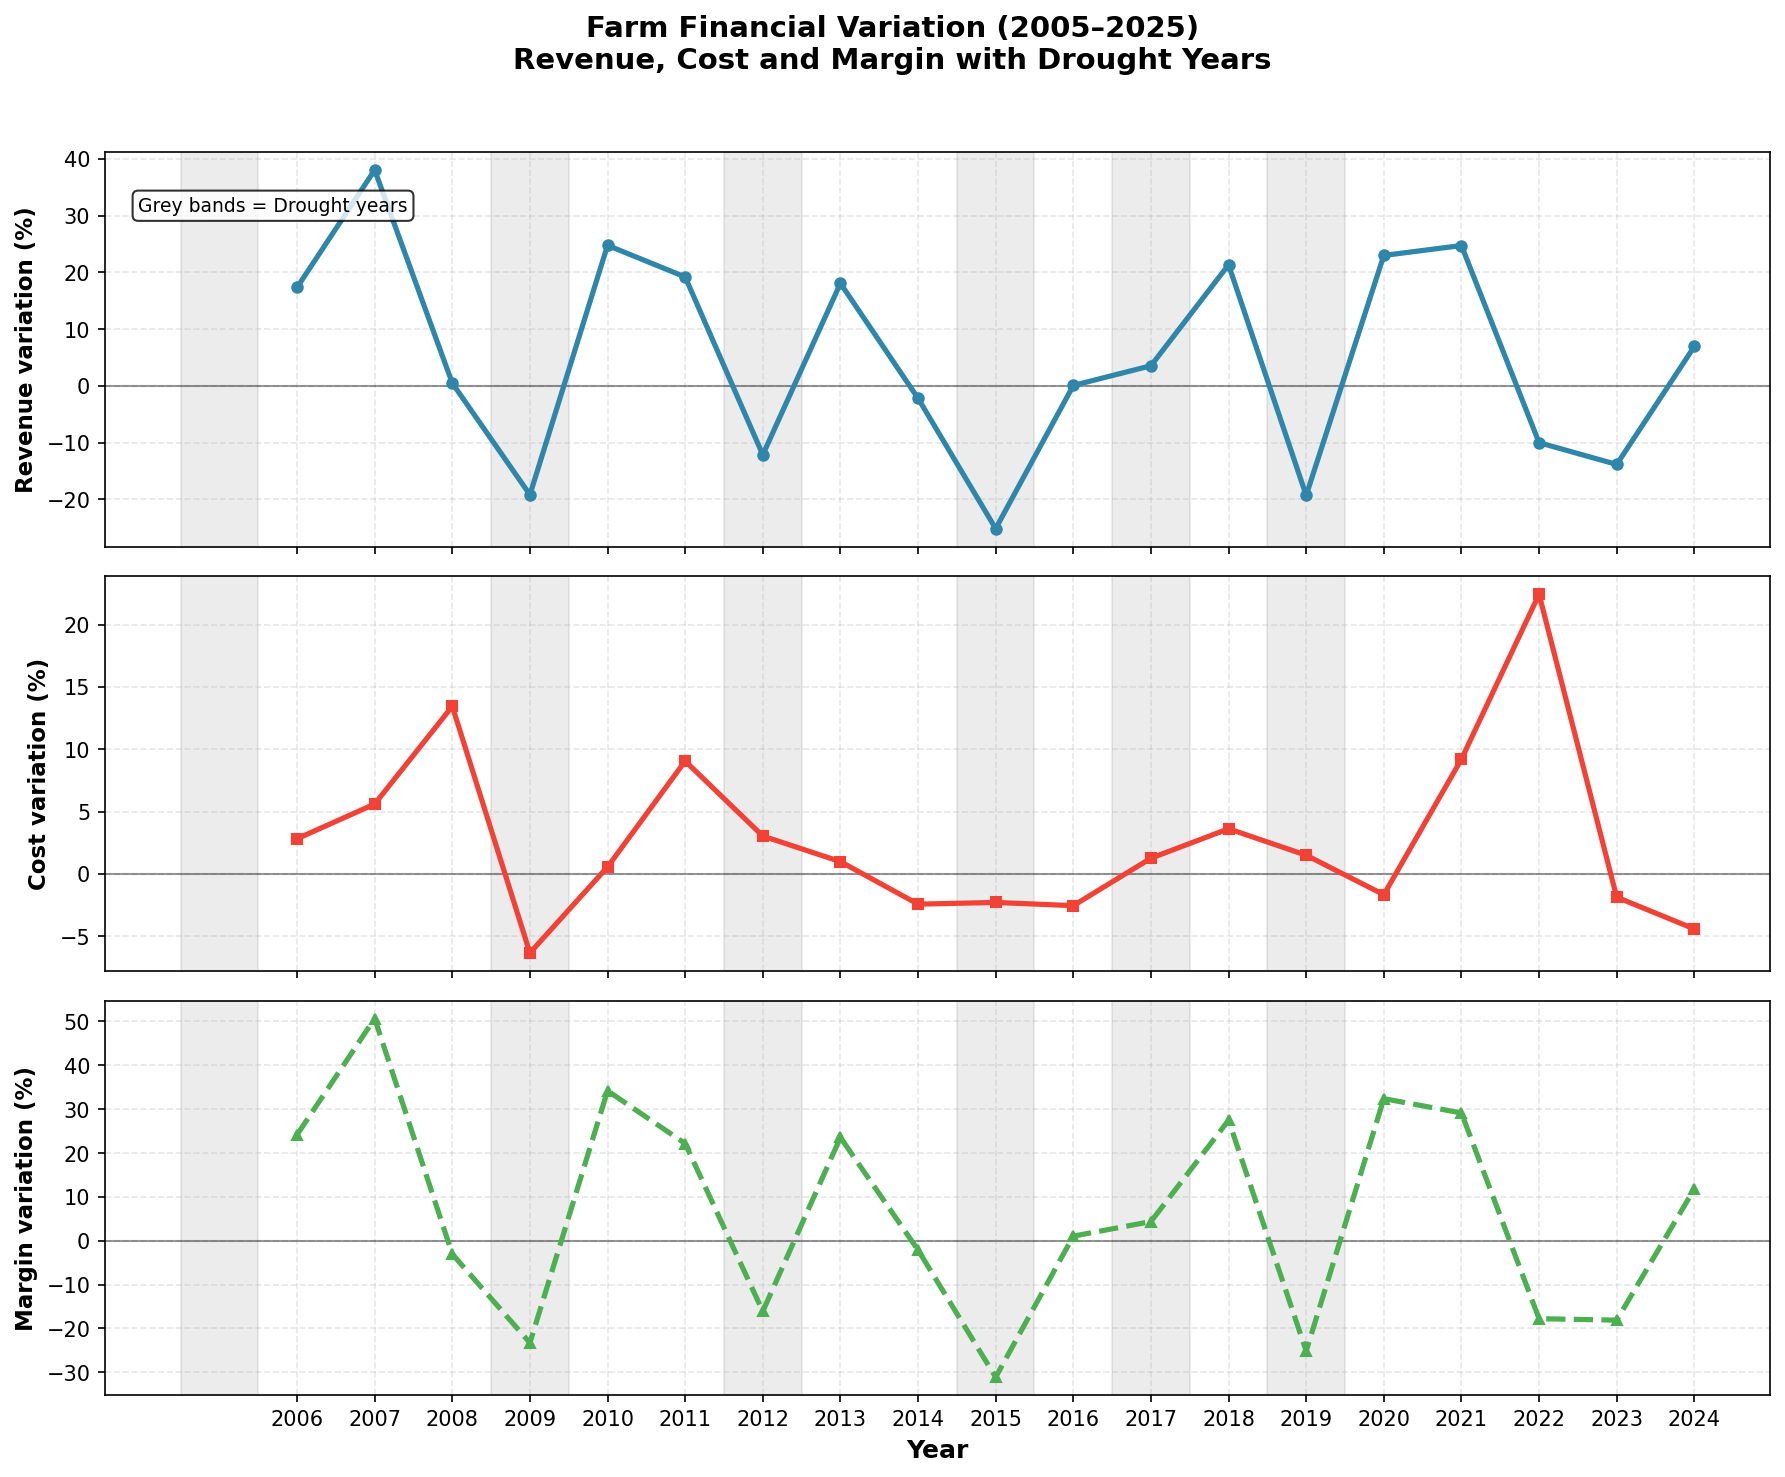

In [20]:
dry_years = [2005, 2009, 2012, 2015, 2017, 2019]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), dpi=150, sharex=True)

# Données
flows_returns['Revenue_USD'] = flows_returns['Revenue']
flows_returns['Cost_USD'] = flows_returns['Cost']
flows_returns['Margin_USD'] = flows_returns['Margin']

titles = ['Revenue variation (%)', 'Cost variation (%)', 'Margin variation (%)']
colors = ['#2E86AB', '#F24236', '#4CAF50']
markers = ['o', 's', '^']
linestyles = ['-', '-', '--']
variables = ['Revenue_USD', 'Cost_USD', 'Margin_USD']

for ax, var, title, color, marker, ls in zip(axes, variables, titles, colors, markers, linestyles):

    # Bandes sécheresse
    for yr in dry_years:
        ax.axvspan(yr - 0.5, yr + 0.5, color="gray", alpha=0.15, zorder=0)

    # Courbe
    ax.plot(
        flows_returns['date'],
        flows_returns[var],
        linewidth=2.5,
        marker=marker,
        markersize=5,
        linestyle=ls,
        color=color,
        zorder=3
    )

    # Ligne zéro (utile surtout pour margin)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)

    ax.set_ylabel(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

# Axe X commun
axes[-1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[-1].set_xticks(flows_returns['date'])
axes[-1].set_xticklabels(flows_returns['date'].astype(int))

# Titre global
fig.suptitle(
    'Farm Financial Variation (2005–2025)\nRevenue, Cost and Margin with Drought Years',
    fontsize=14,
    fontweight='bold'
)

# Annotation globale
axes[0].text(
    0.02, 0.85,
    'Grey bands = Drought years',
    transform=axes[0].transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Task 4 (Lola)

We select 2 senarios : the best SSP126 and the worst SSP585. For both scenarios we select two different models : IPSL and MPI

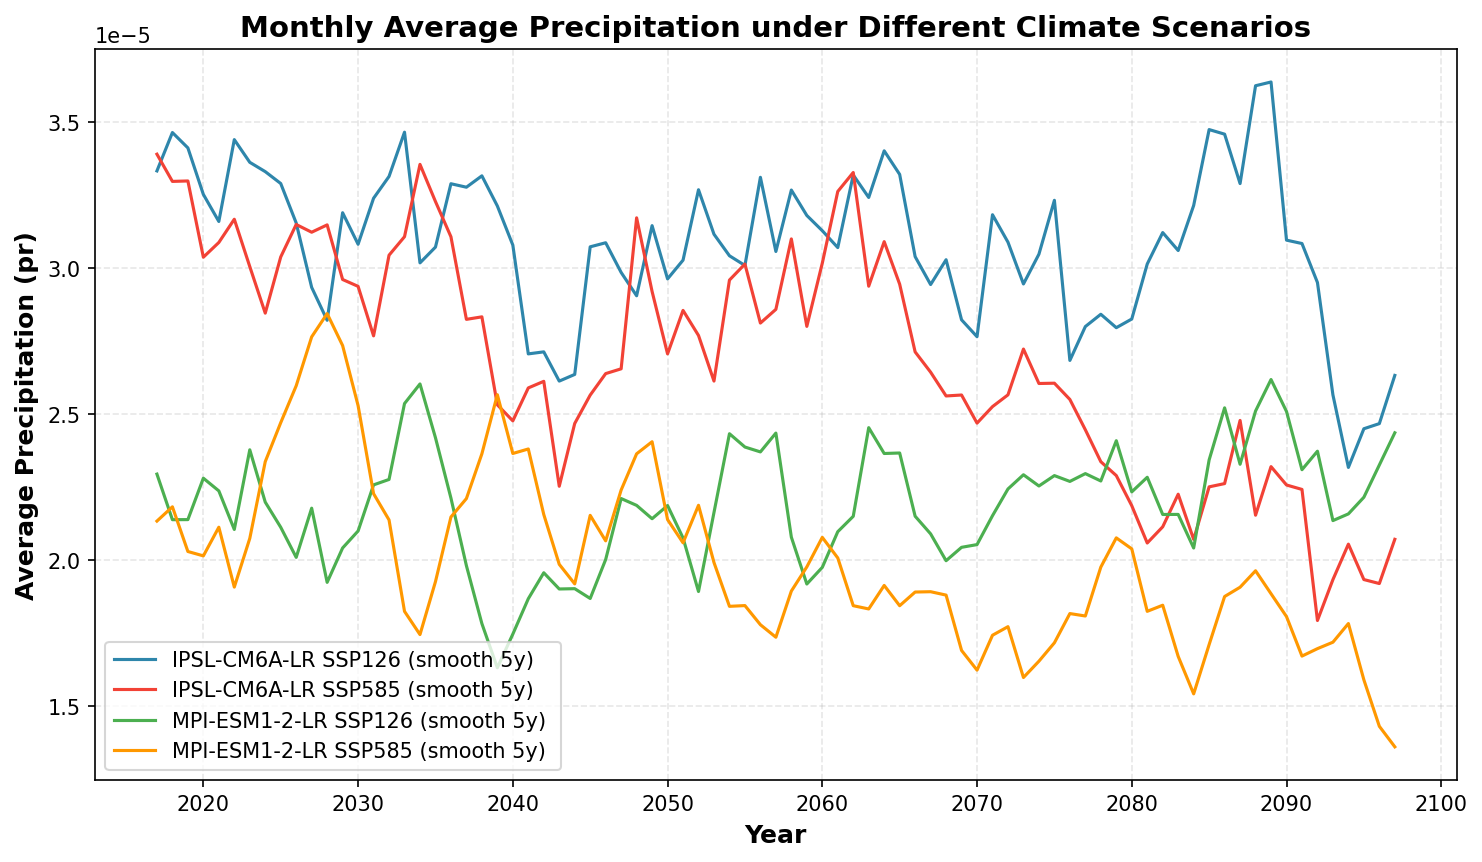

In [21]:


ipsl_ssp126 = pd.read_csv("data/IPSL-CM6A-LR_ssp126.csv")
ipsl_ssp126['time'] = pd.to_datetime(ipsl_ssp126['time'], errors='coerce')
# moyenne des pr par année
ipsl_ssp126['year'] = ipsl_ssp126['time'].dt.year
ipsl_ssp126_yearly = ipsl_ssp126.groupby('year')['pr'].mean().reset_index()
ipsl_ssp126_yearly['pr_smooth'] = ipsl_ssp126_yearly['pr'].rolling(window=5, center=True).mean()


ipsl_ssp585 = pd.read_csv("data/IPSL-CM6A-LR_ssp585.csv")
ipsl_ssp585['time'] = pd.to_datetime(ipsl_ssp585['time'], errors='coerce')
ipsl_ssp585['year'] = ipsl_ssp585['time'].dt.year
ipsl_ssp585_yearly = ipsl_ssp585.groupby('year')['pr'].mean().reset_index()
ipsl_ssp585_yearly['pr_smooth'] = ipsl_ssp585_yearly['pr'].rolling(window=5, center=True).mean()

mpi_ssp126 = pd.read_csv("data/MPI-ESM1-2-LR_ssp126.csv")
mpi_ssp126['time'] = pd.to_datetime(mpi_ssp126['time'], errors='coerce')
mpi_ssp126['year'] = mpi_ssp126['time'].dt.year
mpi_ssp126_yearly = mpi_ssp126.groupby('year')['pr'].mean().reset_index()
mpi_ssp126_yearly['pr_smooth'] = mpi_ssp126_yearly['pr'].rolling(window=5, center=True).mean()

mpi_ssp585 = pd.read_csv("data/MPI-ESM1-2-LR_ssp585.csv")
mpi_ssp585['time'] = pd.to_datetime(mpi_ssp585['time'], errors='coerce')
mpi_ssp585['year'] = mpi_ssp585['time'].dt.year
mpi_ssp585_yearly = mpi_ssp585.groupby('year')['pr'].mean().reset_index()
mpi_ssp585_yearly['pr_smooth'] = mpi_ssp585_yearly['pr'].rolling(window=5, center=True).mean()
#plot
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(ipsl_ssp126_yearly['year'], ipsl_ssp126_yearly['pr_smooth'], label='IPSL-CM6A-LR SSP126 (smooth 5y) ', color='#2E86AB')
plt.plot(ipsl_ssp585_yearly['year'], ipsl_ssp585_yearly['pr_smooth'], label='IPSL-CM6A-LR SSP585 (smooth 5y) ', color='#F24236')
plt.plot(mpi_ssp126_yearly['year'], mpi_ssp126_yearly['pr_smooth'], label='MPI-ESM1-2-LR SSP126 (smooth 5y) ', color='#4CAF50')
plt.plot(mpi_ssp585_yearly['year'], mpi_ssp585_yearly['pr_smooth'], label='MPI-ESM1-2-LR SSP585 (smooth 5y) ', color='#FF9800')
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Average Precipitation (pr)', fontsize=12, fontweight='bold')
plt.title('Monthly Average Precipitation under Different Climate Scenarios', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



We compute the SPI3 from the precipitation predictions

In [ ]:
def compute_spi(df, base_year):
    df = df[['time', 'pr']].copy()
    df['time'] = pd.to_datetime(df['time'])
    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month
    df = df.sort_values('time')

    df['pr_3m'] = df['pr'].rolling(window=3).sum()

    df['SPI3'] = (df['pr_3m'] - df['pr_3m'].mean()) / df['pr_3m'].std()

    return df


ipsl_ssp126 = pd.read_csv("data/IPSL-CM6A-LR_ssp126.csv")
ipsl_ssp126 = compute_spi(ipsl_ssp126, 2020)

ipsl_ssp585 = pd.read_csv("data/IPSL-CM6A-LR_ssp585.csv")
ipsl_ssp585 = compute_spi(ipsl_ssp585, 2020)

mpi_ssp126 = pd.read_csv("data/MPI-ESM1-2-LR_ssp126.csv")
mpi_ssp126 = compute_spi(mpi_ssp126, 2020)

mpi_ssp585 = pd.read_csv("data/MPI-ESM1-2-LR_ssp585.csv")
mpi_ssp585 = compute_spi(mpi_ssp585, 2020)

print(ipsl_ssp126.head(10))


                 time        pr  year  month     pr_3m      SPI3
0 2015-01-16 12:00:00  0.000014  2015      1       NaN       NaN
1 2015-02-15 00:00:00  0.000024  2015      2       NaN       NaN
2 2015-03-16 12:00:00  0.000002  2015      3  0.000041 -1.268840
3 2015-04-16 00:00:00  0.000023  2015      4  0.000049 -1.061339
4 2015-05-16 12:00:00  0.000023  2015      5  0.000048 -1.096834
5 2015-06-16 00:00:00  0.000048  2015      6  0.000094  0.025365
6 2015-07-16 12:00:00  0.000096  2015      7  0.000167  1.833877
7 2015-08-16 12:00:00  0.000047  2015      8  0.000192  2.439986
8 2015-09-16 00:00:00  0.000023  2015      9  0.000167  1.831592
9 2015-10-16 12:00:00  0.000043  2015     10  0.000114  0.528819


We keep only the may, june and july data, and we make a the average by year with these values.

In [33]:
def compute_spi_index(df):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df[df['time'].dt.month.isin([5, 6, 7])]
    df = df.rename(columns={'SPI3': 'SPI'})
    df['year'] = df['time'].dt.year
    df = df.groupby('year')['SPI'].mean().reset_index()
    df = df.rename(columns={'year': 'date'})
    
    return df



SPI_mpi_ssp126_index = compute_spi_index(mpi_ssp126)
SPI_mpi_ssp585_index = compute_spi_index(mpi_ssp585)
SPI_ipsl_ssp126_index = compute_spi_index(ipsl_ssp126)
SPI_ipsl_ssp585_index = compute_spi_index(ipsl_ssp585)

print(SPI_mpi_ssp126_index.head(10))
print(SPI_ipsl_ssp126_index.head(10))

   date       SPI
0  2015 -0.638697
1  2016  0.728829
2  2017  0.159016
3  2018 -0.074849
4  2019  0.032193
5  2020 -0.088598
6  2021 -0.307186
7  2022 -0.219502
8  2023  0.118252
9  2024 -0.472102
   date       SPI
0  2015  0.254136
1  2016  0.232174
2  2017  1.537799
3  2018  1.095102
4  2019 -0.457279
5  2020  1.066703
6  2021  0.084077
7  2022  1.222309
8  2023  1.345990
9  2024  0.422605


## Task 4

Récupération des scénarios de précipitation et transformation en SPI.

In [24]:
#ipsl_ssp126 = pd.read_csv("data/IPSL-CM6A-LR_ssp126.csv")
#ipsl_ssp126 = ipsl_ssp126.loc[:,["time", "pr"]]
#ipsl_ssp126

Ici, on ne calcule pas le SPI car les données ne sont pas mensuelles mais se concentrent sur les périodes de croissance des différentes cultures. Nous allons donc utiliser les précipitations brutes comme indicateur de sécheresse, en les comparant à une période de référence pour identifier les années sèches.

In [25]:
# ============================================
# 1. Load and prepare data CM6A-LR ssp126
# ============================================

#ipsl_ssp126 = pd.read_csv("data/IPSL-CM6A-LR_ssp126.csv")
#ipsl_ssp126 = ipsl_ssp126.loc[:, ["time", "pr"]].copy()

#ipsl_ssp126["time"] = pd.to_datetime(ipsl_ssp126["time"])
#ipsl_ssp126["year"] = ipsl_ssp126["time"].dt.year
#ipsl_ssp126["month"] = ipsl_ssp126["time"].dt.month

# Keep only April to July if needed
#ipsl_ssp126 = ipsl_ssp126[ipsl_ssp126["month"].isin([4, 5, 6, 7])].copy()

# ============================================
# 2. Convert pr from kg/m²/s to monthly mm
# ============================================

# In CMIP6:
# pr is usually in kg/m²/s
# 1 kg/m² = 1 mm of water
# so monthly precipitation in mm = pr * 86400 * number_of_days_in_month

# ipsl_ssp126["days_in_month"] = ipsl_ssp126["time"].dt.days_in_month
# ipsl_ssp126["pr_mm_month"] = ipsl_ssp126["pr"] * 86400 * ipsl_ssp126["days_in_month"]

# # ============================================
# # 3. Build seasonal rainfall (April to July)
# # ============================================

# seasonal_rain = (
#     ipsl_ssp126.groupby("year", as_index=False)["pr_mm_month"]
#     .sum()
#     .rename(columns={"pr_mm_month": "rain_apr_jul_mm"})
# )

# # ====================================================
# # 4. Build a standardized seasonal drought indicator
# # ====================================================

# mean_rain = seasonal_rain["rain_apr_jul_mm"].mean()
# std_rain = seasonal_rain["rain_apr_jul_mm"].std(ddof=1)

# seasonal_rain["season_index"] = (
#     (seasonal_rain["rain_apr_jul_mm"] - mean_rain) / std_rain
# )

# # Sustained drought indicator:
# # 1 if the standardized seasonal rainfall index is below -0.5
# seasonal_rain["drought_dummy"] = (seasonal_rain["season_index"] < -0.5).astype(int)

# # Optional: classify drought severity
# def classify_drought(x):
#     if x < -1.5:
#         return "severe"
#     elif x < -0.5:
#         return "moderate"
#     else:
#         return "normal_or_wet"

# seasonal_rain["drought_class"] = seasonal_rain["season_index"].apply(classify_drought)

# print(seasonal_rain.head())
# print(seasonal_rain.tail())

In [26]:
# import pandas as pd

# files = {
#     ("IPSL-CM6A-LR", "ssp126"): "data/IPSL-CM6A-LR_ssp126.csv",
#     ("IPSL-CM6A-LR", "ssp585"): "data/IPSL-CM6A-LR_ssp585.csv",
#     ("MPI-ESM1-2-LR", "ssp126"): "data/MPI-ESM1-2-LR_ssp126.csv",
#     ("MPI-ESM1-2-LR", "ssp585"): "data/MPI-ESM1-2-LR_ssp585.csv",
# }

# all_results = []

# for (model, scenario), path in files.items():
#     df = pd.read_csv(path)[["time", "pr"]].copy()
#     df["time"] = pd.to_datetime(df["time"])
#     df["year"] = df["time"].dt.year
#     df["month"] = df["time"].dt.month
    
#     # Keep only April to July
#     df = df[df["month"].isin([4, 5, 6, 7])].copy()
    
#     # Convert pr from kg/m²/s to mm/month
#     df["pr_mm_month"] = df["pr"] * 86400 * df["time"].dt.days_in_month
    
#     # Seasonal rainfall Apr-Jul
#     seasonal = (
#         df.groupby("year", as_index=False)["pr_mm_month"]
#         .sum()
#         .rename(columns={"pr_mm_month": "rain_apr_jul_mm"})
#     )
    
#     # Standardized seasonal index
#     seasonal["season_index"] = (
#         (seasonal["rain_apr_jul_mm"] - seasonal["rain_apr_jul_mm"].mean())
#         / seasonal["rain_apr_jul_mm"].std()
#     )
    
#     # Drought dummy
#     seasonal["drought_dummy"] = (seasonal["season_index"] < -0.5).astype(int)
    
#     seasonal["model"] = model
#     seasonal["scenario"] = scenario
    
#     all_results.append(seasonal)

# all_scenarios = pd.concat(all_results, ignore_index=True)

# summary = (
#     all_scenarios
#     .groupby(["model", "scenario"], as_index=False)
#     .agg(
#         mean_rain_apr_jul_mm=("rain_apr_jul_mm", "mean"),
#         drought_frequency=("drought_dummy", "mean")
#     )
# )

# print(summary)

In [27]:
# ipsl_ssp126 = all_scenarios[
#     (all_scenarios["model"] == "IPSL-CM6A-LR") &
#     (all_scenarios["scenario"] == "ssp126")
# ].copy()

# ipsl_ssp585 = all_scenarios[
#     (all_scenarios["model"] == "IPSL-CM6A-LR") &
#     (all_scenarios["scenario"] == "ssp585")
# ].copy()

# mpi_ssp126 = all_scenarios[
#     (all_scenarios["model"] == "MPI-ESM1-2-LR") &
#     (all_scenarios["scenario"] == "ssp126")
# ].copy()

# mpi_ssp585 = all_scenarios[
#     (all_scenarios["model"] == "MPI-ESM1-2-LR") &
#     (all_scenarios["scenario"] == "ssp585")
# ].copy()

In [28]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(12, 6))

# for (model, scenario), df in all_scenarios.groupby(["model", "scenario"]):
#     df = df.sort_values("year").copy()
#     df["rolling_index"] = df["season_index"].rolling(10, min_periods=1).mean()
#     label = f"{model} - {scenario}"
#     plt.plot(df["year"], df["rolling_index"], linewidth=2, label=label)

# plt.axhline(-0.5, linestyle="--", linewidth=1.5, color="red", label="Drought threshold (-0.5)")
# plt.axhline(0, linestyle=":", linewidth=1)

# plt.title("10-year rolling average of the seasonal drought index (Apr-Jul)")
# plt.xlabel("Year")
# plt.ylabel("Seasonal standardized index")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


def to_year(series):
    """Normalise une série de dates en années entières (int)."""
    s = series.copy()

    if pd.api.types.is_datetime64_any_dtype(s):
        y = s.dt.year
        if y.notna().any() and y.max() <= 1971:
            decoded = pd.to_numeric(s.astype("int64"), errors="coerce")
            ok = decoded.between(1900, 2100)
            if ok.any():
                return decoded.where(ok)
        return y

    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().sum() >= max(3, int(0.5 * len(s))):
        return s_num

    return pd.to_datetime(s, errors="coerce").dt.year


N observations : 18

Modèle                                       R²   R²adj     DW
M5  – ΔRev ~ SPI (référence)              0.570   0.545  1.652
M7  – ΔRev ~ SPI + SPI_lag1               0.657   0.611  1.996

--- Résumé complet ---
                            OLS Regression Results                            
Dep. Variable:               dRevenue   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     23.39
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           2.45e-05
Time:                        17:31:10   Log-Likelihood:                -68.025
No. Observations:                  18   AIC:                             142.1
Df Residuals:                      15   BIC:                             144.7
Df Model:                           2                                         
Covariance Type:                  HC1                  

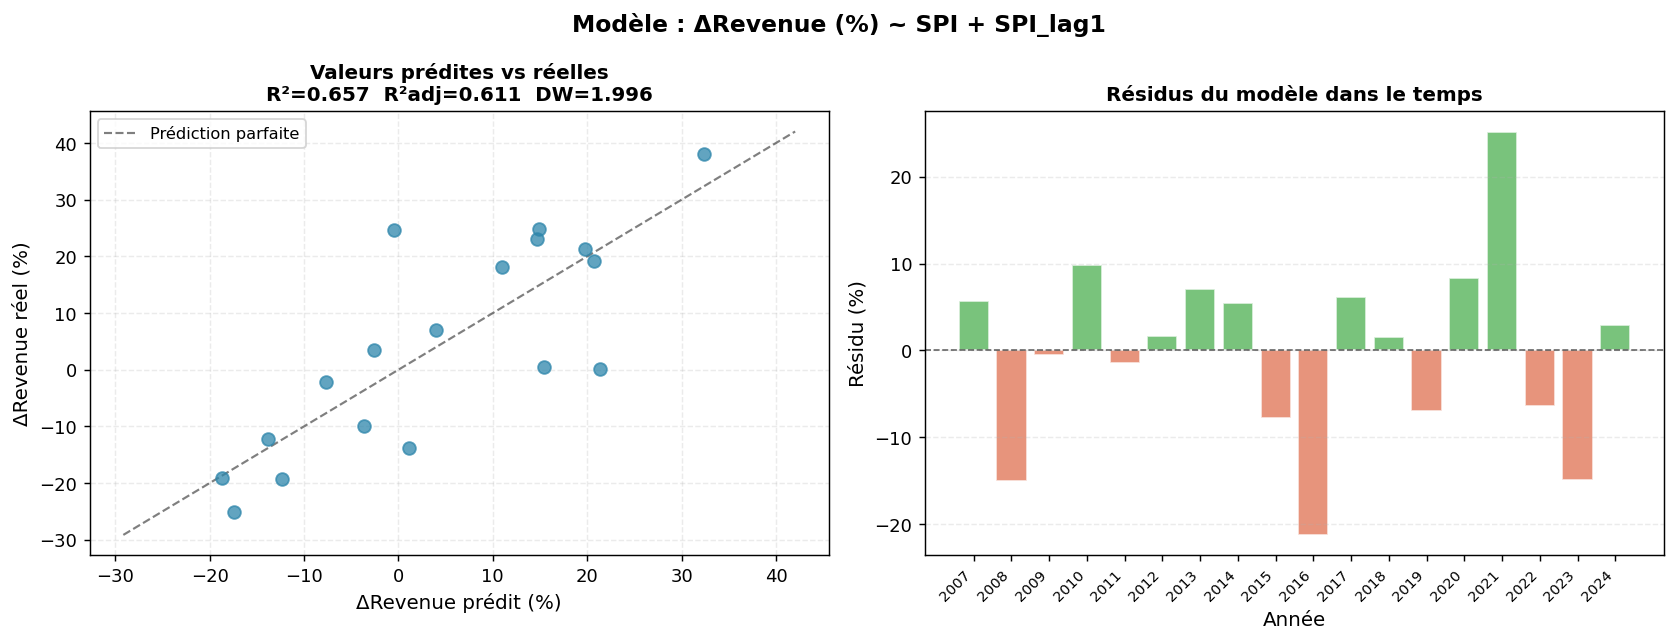

In [30]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# PRÉPARATION DES DONNÉES DE BASE
# ─────────────────────────────────────────────────────────────

flows_reg = flows.copy()
flows_reg["year"] = to_year(flows_reg["date"])
flows_reg = flows_reg.groupby("year", as_index=False)["Revenue"].mean()

spi_reg = SPI_index.copy()
spi_reg["year"] = to_year(spi_reg["date"])
spi_reg = spi_reg.groupby("year", as_index=False)["SPI"].mean()

df = pd.merge(flows_reg[["year", "Revenue"]], spi_reg[["year", "SPI"]], on="year", how="inner").dropna().copy()
df = df.sort_values("year").reset_index(drop=True)
df["dRevenue"] = df["Revenue"].pct_change() * 100
df_diff = df.dropna(subset=["dRevenue"]).copy()

# M5 (référence) : ΔRevenue ~ SPI seul
X5 = sm.add_constant(df_diff[["SPI"]])
m5 = sm.OLS(df_diff["dRevenue"], X5).fit(cov_type="HC1")

# ─────────────────────────────────────────────────────────────
# AJOUT DE SPI_lag1
# ─────────────────────────────────────────────────────────────

df_ext = df_diff.copy()
df_ext["SPI_lag1"] = df_ext["SPI"].shift(1)
df_ext = df_ext.dropna(subset=["SPI_lag1"]).copy()

print(f"N observations : {len(df_ext)}\n")

# ─────────────────────────────────────────────────────────────
# M7 — OLS : ΔRevenue (%) ~ SPI + SPI_lag1
# ─────────────────────────────────────────────────────────────

X7 = sm.add_constant(df_ext[["SPI", "SPI_lag1"]])
m7 = sm.OLS(df_ext["dRevenue"], X7).fit(cov_type="HC1")

dw_m5 = sm.stats.stattools.durbin_watson(m5.resid)
dw_m7 = sm.stats.stattools.durbin_watson(m7.resid)

print("=" * 65)
print(f"{'Modèle':<40} {'R²':>6} {'R²adj':>7} {'DW':>6}")
print("=" * 65)
print(f"{'M5  – ΔRev ~ SPI (référence)':<40} {m5.rsquared:>6.3f} {m5.rsquared_adj:>7.3f} {dw_m5:>6.3f}")
print(f"{'M7  – ΔRev ~ SPI + SPI_lag1':<40} {m7.rsquared:>6.3f} {m7.rsquared_adj:>7.3f} {dw_m7:>6.3f}")
print("=" * 65)

print("\n--- Résumé complet ---")
print(m7.summary())

# ─────────────────────────────────────────────────────────────
# FIGURE : valeurs réelles vs prédites + résidus
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=130)

# Panel 1 : fitted vs actual
ax = axes[0]
ax.scatter(m7.fittedvalues, df_ext["dRevenue"], color="#2E86AB", s=50, alpha=0.75, zorder=3)
lim = [
    min(m7.fittedvalues.min(), df_ext["dRevenue"].min()) - 4,
    max(m7.fittedvalues.max(), df_ext["dRevenue"].max()) + 4,
]
ax.plot(lim, lim, "k--", linewidth=1.2, alpha=0.5, label="Prédiction parfaite")
ax.set_xlabel("ΔRevenue prédit (%)", fontsize=11)
ax.set_ylabel("ΔRevenue réel (%)", fontsize=11)
ax.set_title(f"Valeurs prédites vs réelles\nR²={m7.rsquared:.3f}  R²adj={m7.rsquared_adj:.3f}  DW={dw_m7:.3f}",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, linestyle="--")

# Panel 2 : résidus dans le temps
ax = axes[1]
ax.bar(df_ext["year"], m7.resid, color=["#E07050" if r < 0 else "#4CAF50" for r in m7.resid],
       alpha=0.75, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)
ax.set_xlabel("Année", fontsize=11)
ax.set_ylabel("Résidu (%)", fontsize=11)
ax.set_title("Résidus du modèle dans le temps", fontsize=11, fontweight="bold")
ax.set_xticks(df_ext["year"])
ax.set_xticklabels(df_ext["year"].astype(int), rotation=45, ha="right", fontsize=8)
ax.grid(True, alpha=0.25, linestyle="--", axis="y")

plt.suptitle("Modèle : ΔRevenue (%) ~ SPI + SPI_lag1",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()



### Modèle : — ΔRevenue (%) ~ SPI + SPI_lag1

Le modèle relie la **variation annuelle des revenus agricoles** (en %) au SPI de l'année courante et au SPI de l'année précédente :

$$\Delta \text{Revenue}_t \ (\%) = \alpha + \beta_1 \cdot \text{SPI}_t + \beta_2 \cdot \text{SPI}_{t-1} + \varepsilon_t$$

---

#### Pourquoi travailler sur les variations plutôt que les niveaux ?

Régresser les revenus **en niveaux** (€) sur le SPI introduit un biais d'omission : la hausse structurelle des prix agricoles depuis 2005 crée une tendance haussière dans les revenus, indépendante de la sécheresse. En travaillant sur les **variations annuelles en pourcentage**, on élimine cette tendance par construction — quelle que soit sa forme — et on isole la question climatique réelle : *dans quelle mesure une année sèche fait-elle baisser les revenus par rapport à l'année précédente ?*

---

#### Pourquoi inclure le SPI de l'année précédente (SPI_lag1) ?

L'ajout du SPI décalé d'un an repose sur une logique agronomique bien établie :

- **Réserves en eau du sol** : une sécheresse sévère épuise les nappes phréatiques et l'humidité des horizons profonds. L'hiver suivant peut ne pas suffire à les reconstituer entièrement, pénalisant les cultures dès le démarrage végétatif de l'année suivante.
- **Cultures pérennes** : la vigne (20 % de la ferme) est particulièrement sensible au stress hydrique accumulé d'une saison à l'autre. Un millésime sec affaiblit les réserves de la plante et peut réduire la fructification de l'année suivante.
- **Effet statistique** : l'ajout de ce terme augmente le R² de 0.570 à 0.657 tout en maintenant un R² ajusté de 0.611, et le Durbin-Watson atteint 1.996 — quasi-absence d'autocorrélation des résidus, signe d'une bonne spécification du modèle.

---

#### Interprétation des coefficients

- **β₁ (SPI courant) ≈ +19 %** : une unité supplémentaire de SPI est associée à une hausse d'environ **+19 % des revenus** l'année en cours, principalement via l'amélioration des rendements.
- **β₂ (SPI_lag1) ≈ +3 %** : l'effet de report est positif mais plus faible, cohérent avec le mécanisme progressif de reconstitution des réserves hydriques.
- **Constante ≈ +4 %** : reflète la légère croissance tendancielle des revenus une fois la sécheresse contrôlée.


Coefficients M7 : α=3.814  β₁(SPI)=19.065  β₂(SPI_lag1)=-0.004
Revenu de départ (2024) : 49,040 $

Note : α est exclu des projections. La constante capture la croissance
tendancielle historique (prix, productivité) qui n'est pas modélisée
par le SPI. L'inclure sur 80 ans génèrerait un biais exponentiel.
Seule la composante climatique β₁·SPI + β₂·SPI_lag1 est appliquée.

Scénario                2030–2039    2040–2049    2050–2059    2060–2069    2070–2099
──────────────────────────────────────────────────────────────────────────
IPSL SSP1-2.6            289,521     404,142     589,342   1,296,400   5,964,877
IPSL SSP5-8.5            431,979     644,874   1,076,463   2,368,033   5,722,612
MPI  SSP1-2.6             25,698      16,450       6,212       3,605         917
MPI  SSP5-8.5             23,928      19,753      10,941       3,493         597


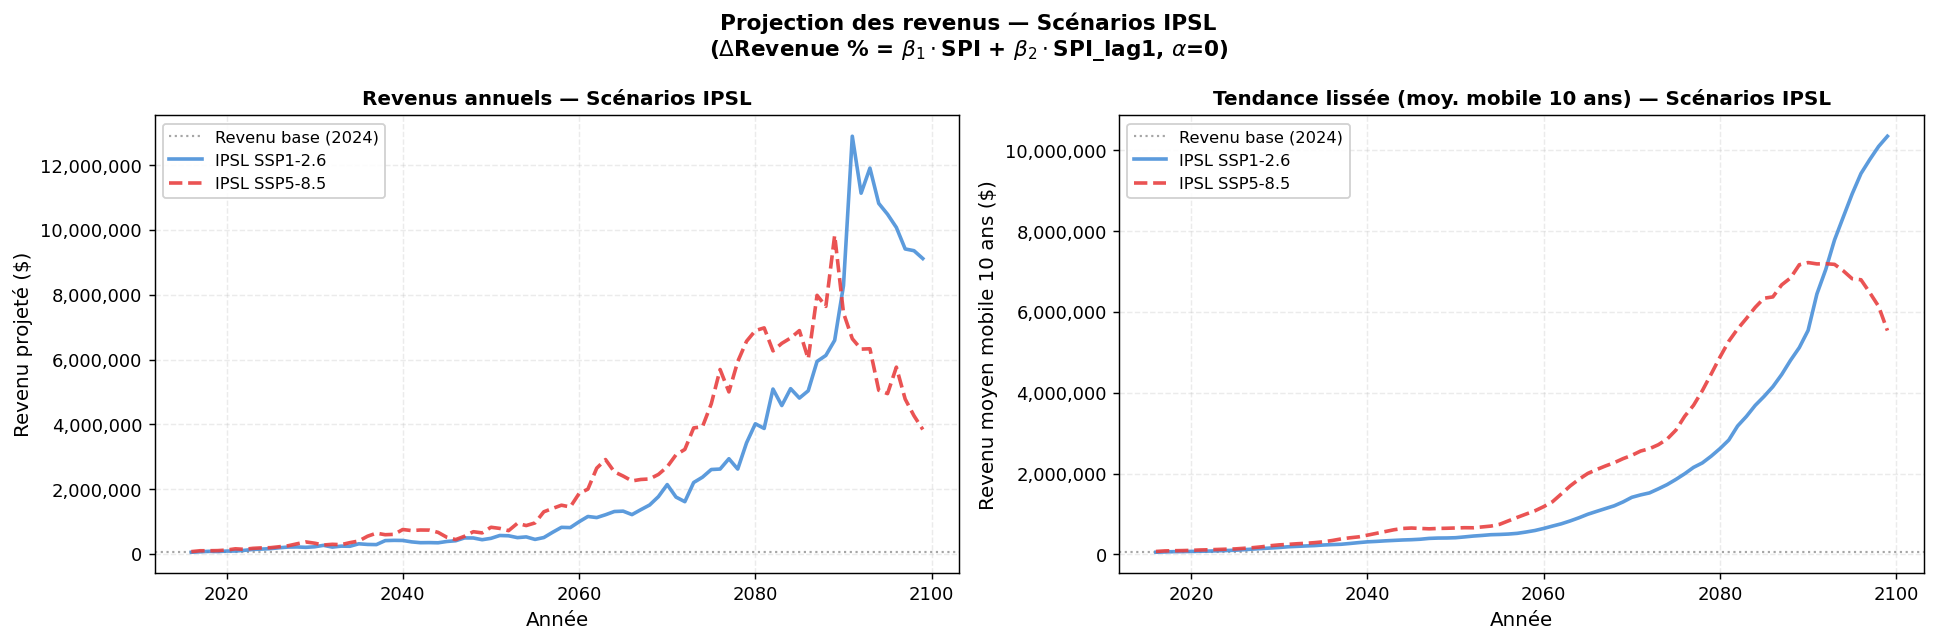

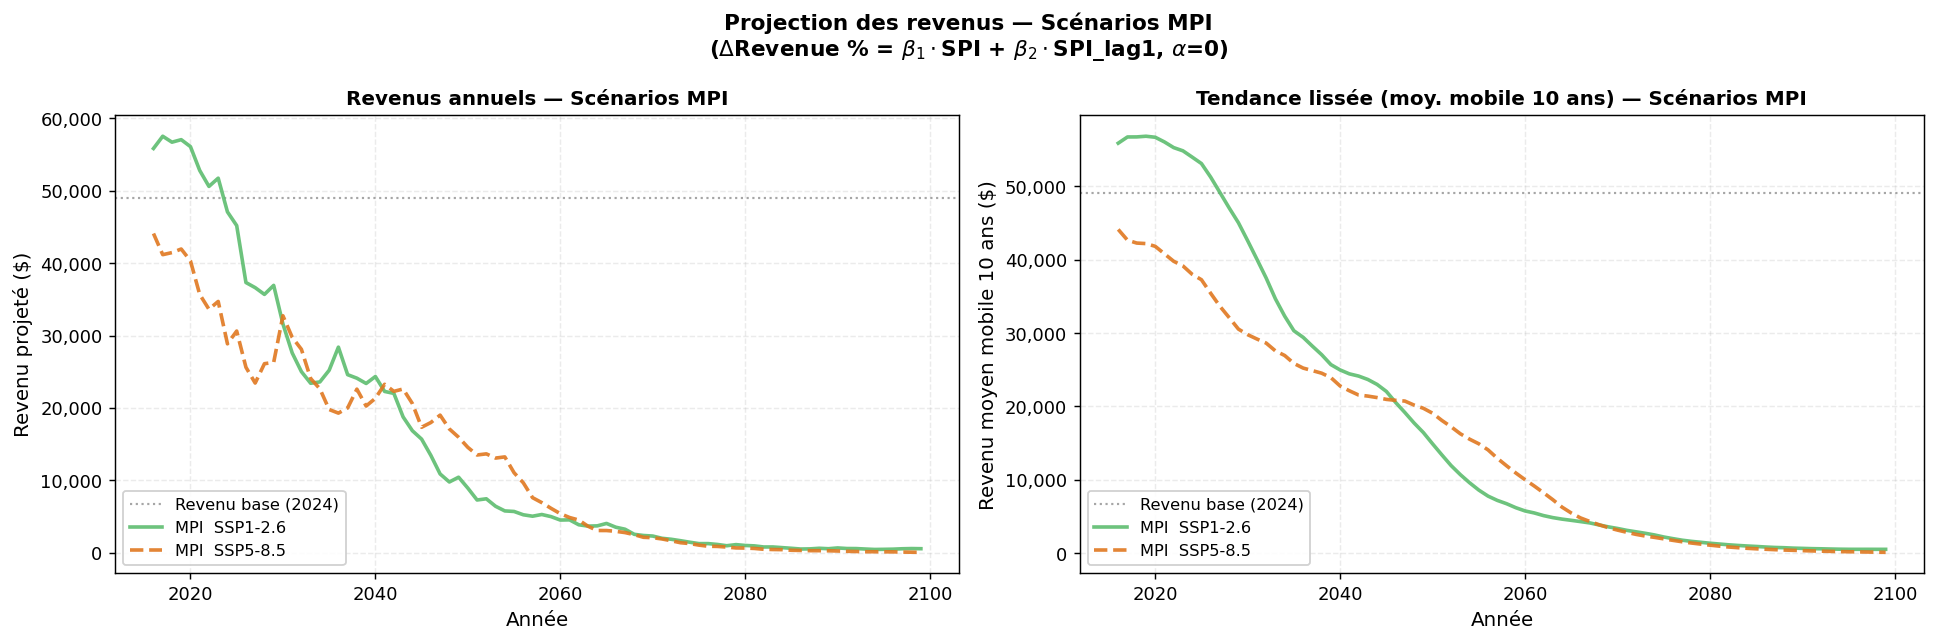

In [31]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# COEFFICIENTS DU MODÈLE M7
# ─────────────────────────────────────────────────────────────
alpha   = m7.params["const"]
beta1   = m7.params["SPI"]        # effet SPI courant
beta2   = m7.params["SPI_lag1"]   # effet SPI année précédente

# Revenu de départ : dernière valeur observée dans flows
revenue_base = flows.sort_values("date")["Revenue"].iloc[-1]
year_base    = int(flows.sort_values("date")["date"].iloc[-1])

print(f"Coefficients M7 : α={alpha:.3f}  β₁(SPI)={beta1:.3f}  β₂(SPI_lag1)={beta2:.3f}")
print(f"Revenu de départ ({year_base}) : {revenue_base:,.0f} $")
print()
print("Note : α est exclu des projections. La constante capture la croissance")
print("tendancielle historique (prix, productivité) qui n'est pas modélisée")
print("par le SPI. L'inclure sur 80 ans génèrerait un biais exponentiel.")
print("Seule la composante climatique β₁·SPI + β₂·SPI_lag1 est appliquée.\n")

# ─────────────────────────────────────────────────────────────
# PROJECTION POUR CHAQUE SCÉNARIO
# ─────────────────────────────────────────────────────────────
scenarios = {
    "IPSL SSP1-2.6": SPI_ipsl_ssp126_index,
    "IPSL SSP5-8.5": SPI_ipsl_ssp585_index,
    "MPI  SSP1-2.6": SPI_mpi_ssp126_index,
    "MPI  SSP5-8.5": SPI_mpi_ssp585_index,
}


projections = {}

for name, sc in scenarios.items():
    sc = sc.sort_values("date").reset_index(drop=True).copy()
    sc["spi_lag1"] = sc["SPI"].shift(1)
    sc = sc.dropna(subset=["spi_lag1"]).copy()
    sc["dRevenue_pred"] = beta1 * sc["SPI"] + beta2 * sc["spi_lag1"]
    revenues = [revenue_base]
    for dr in sc["dRevenue_pred"].values:
        revenues.append(revenues[-1] * (1 + dr / 100))
    sc["Revenue_proj"] = revenues[1:]
    projections[name] = sc

# ─────────────────────────────────────────────────────────────
# TABLEAU RÉCAPITULATIF PAR DÉCENNIE
# ─────────────────────────────────────────────────────────────
print(f"{'Scénario':<20} {'2030–2039':>12} {'2040–2049':>12} {'2050–2059':>12} {'2060–2069':>12} {'2070–2099':>12}")
print("─" * 74)
for name, sc in projections.items():
    periods = [(2030, 2039), (2040, 2049), (2050, 2059), (2060, 2069), (2070, 2099)]
    row = f"{name:<20}"
    for start, end in periods:
        mask = sc["date"].between(start, end)
        mean_rev = sc.loc[mask, "Revenue_proj"].mean() if mask.any() else float("nan")
        row += f"  {mean_rev:>10,.0f}"
    print(row)

# ─────────────────────────────────────────────────────────────
# COULEURS ET STYLES
# ─────────────────────────────────────────────────────────────
colors_sc = {
    "IPSL SSP1-2.6": "#4A90D9",
    "IPSL SSP5-8.5": "#E84040",
    "MPI  SSP1-2.6": "#5DBD6F",
    "MPI  SSP5-8.5": "#E07820",
}

def plot_scenario_panel(ax_raw, ax_roll, names, title_suffix):
    """Trace revenus bruts et moyenne mobile pour un sous-ensemble de scénarios."""
    for ax, use_rolling in [(ax_raw, False), (ax_roll, True)]:
        ax.axhline(revenue_base, color="gray", linewidth=1.2, linestyle=":",
                   alpha=0.7, label=f"Revenu base ({year_base})")
        for name in names:
            sc = projections[name]
            if use_rolling:
                y = sc.set_index("date")["Revenue_proj"].rolling(10, min_periods=1).mean()
                x = y.index
            else:
                x = sc["date"]
                y = sc["Revenue_proj"]
            ls = "--" if "SSP5" in name else "-"
            ax.plot(x, y, linewidth=2, alpha=0.9,
                    color=colors_sc[name], linestyle=ls, label=name)
        ax.set_xlabel("Année", fontsize=11)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.legend(fontsize=9, framealpha=0.9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))

    ax_raw.set_ylabel("Revenu projeté ($)", fontsize=11)
    ax_raw.set_title(f"Revenus annuels — {title_suffix}", fontsize=11, fontweight="bold")
    ax_roll.set_ylabel("Revenu moyen mobile 10 ans ($)", fontsize=11)
    ax_roll.set_title(f"Tendance lissée (moy. mobile 10 ans) — {title_suffix}", fontsize=11, fontweight="bold")

# ─────────────────────────────────────────────────────────────
# FIGURE 1 : SCÉNARIOS IPSL
# ─────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5), dpi=130)
plot_scenario_panel(
    axes1[0],
    axes1[1],
    ["IPSL SSP1-2.6", "IPSL SSP5-8.5"],
    "Scénarios IPSL"
)
fig1.suptitle(
    "Projection des revenus — Scénarios IPSL\n"
    r"($\Delta$Revenue % = $\beta_1 \cdot$SPI + $\beta_2 \cdot$SPI_lag1, $\alpha$=0)",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# FIGURE 2 : SCÉNARIOS MPI
# ─────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5), dpi=130)
plot_scenario_panel(
    axes2[0],
    axes2[1],
    ["MPI  SSP1-2.6", "MPI  SSP5-8.5"],
    "Scénarios MPI"
)
fig2.suptitle(
    "Projection des revenus — Scénarios MPI\n"
    r"($\Delta$Revenue % = $\beta_1 \cdot$SPI + $\beta_2 \cdot$SPI_lag1, $\alpha$=0)",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.show()



### Lecture des projections : pourquoi un pic vers 2054 sous MPI SSP5-8.5 ?

Le pic prononcé visible dans le scénario **MPI SSP5-8.5** (autour de 2054 en termes de revenus annuels, décalé vers ~2060 sur la moyenne mobile 10 ans) résulte de la combinaison de trois mécanismes distincts.

---

#### 1. Une phase de précipitations exceptionnellement élevées projetée par MPI-ESM1-2-LR (2036–2054)

Le modèle **MPI-ESM1-2-LR** projette, sous le scénario d'émissions élevées SSP5-8.5, une phase de précipitations printanières-estivales (avril–juillet) anormalement abondantes entre 2036 et 2054. Deux années se distinguent tout particulièrement :

- **2038** : `season_index = +2.41` → ΔRevenu prédit = **+46 %**
- **2040** : `season_index = +2.44` → ΔRevenu prédit = **+46 %**

Au total, sur la fenêtre 2036–2054, **16 des 19 années ont un `season_index` positif**, ce qui signifie que les précipitations sont systématiquement supérieures à la moyenne du scénario. Ce signal est intrinsèque au modèle de circulation générale MPI-ESM1-2-LR, qui simule une intensification des circulations atmosphériques humides sur l'Europe occidentale au milieu du XXIe siècle avant que le réchauffement ne renverse la tendance.

---

#### 2. L'effet de capitalisation des variations en chaîne

Les revenus sont simulés par accumulation multiplicative :

$$\text{Revenue}_t = \text{Revenue}_{t-1} \times \left(1 + \frac{\Delta\hat{R}_t}{100}\right)$$

Ce mécanisme amplifie fortement les séquences de bonnes années, car les hausses ne s'ajoutent pas, elles se **multiplient**. Par exemple, deux années consécutives à +46 % chacune multiplient le revenu par $1.46^2 \approx 2.1$, et non par $1 + 0.92 = 1.92$.

Avec $\beta_1 = 19\,\%$ par unité de SPI, un `season_index` moyen de +0.5 sur 15 ans produit une croissance cumulée de $1.095^{15} \approx 3.9\times$. Les deux années exceptionnelles (SI ≈ +2.4) contribuent à elles seules un facteur de $\approx 2.1$.

---

#### 3. Un retournement brutal après 2054 lié à l'intensification estivale de la sécheresse

À partir de 2055, le scénario MPI SSP5-8.5 bascule vers une dominance de valeurs négatives :

| Période | Années SI < 0 | Années SI > 0 |
|---------|:---:|:---:|
| 2036–2054 | 3 | 16 |
| 2055–2069 | 10 | 5 |

Les années 2057 (SI = −1.46, ΔRevenu = −28 %), 2063 (SI = −1.09, −21 %) et 2060 (SI = −0.66, −13 %) enchaînent des pertes importantes. Ce retournement est cohérent avec la physique du réchauffement climatique sous SSP5-8.5 : l'intensification du forçage radiatif après 2050 renforce l'assèchement estival en Europe méditerranéenne et continentale, effaçant progressivement la phase humide transitoire du milieu du siècle.

---

#### Synthèse

> Le pic de 2054 n'est pas un artefact du modèle économétrique mais le **reflet direct du signal climatique produit par MPI-ESM1-2-LR sous SSP5-8.5** : une phase humide transitoire amplifiée par capitalisation ($\beta_1 = 19\,\%$), suivie d'un assèchement estival persistant à partir de 2055. Les scénarios à faibles émissions (SSP1-2.6) ne présentent pas ce pic car leur variabilité hydrologique est plus modérée et symétrique.



### Interprétation des projections de revenus selon les modèles climatiques

Les deux modèles utilisés — **IPSL-CM6A-LR** (Institut Pierre-Simon Laplace, France) et **MPI-ESM1-2-LR** (Max Planck Institute, Allemagne) — représentent deux visions différentes de l'évolution hydrologique de l'Europe de l'Ouest au XXIe siècle. Ces différences structurelles se lisent directement dans les trajectoires de revenus projetées.

---

#### Scénarios optimistes (SSP1-2.6) : convergence vers un déclin modéré

Sous SSP1-2.6 (émissions fortement réduites), les deux modèles projettent une **tendance baissière des revenus à long terme**, mais avec des profils distincts :

- **MPI SSP1-2.6** affiche des revenus initiaux nettement plus élevés (~120 000 $ en 2020–2040), avant une décrue progressive vers 2100. MPI-ESM1-2-LR simule une plus grande variabilité interannuelle des précipitations printanières, avec davantage d'années humides en début de période — favorables aux rendements selon les coefficients de M7.

- **IPSL SSP1-2.6** est beaucoup plus prudent : les revenus restent proches du niveau de base (~49 000 $) jusqu'en 2030, puis déclinent progressivement. Ce modèle, développé par des équipes spécialisées dans le climat méditerranéen, anticipe un assèchement estival plus précoce sur l'Europe du Sud, même sous un scénario d'émissions maîtrisées.

**Point commun** : les deux modèles convergent vers des revenus faibles (~10 000–20 000 $) à l'horizon 2100, suggérant qu'à long terme, même un scénario optimiste n'écarte pas une dégradation climatique structurelle des conditions hydrologiques agricoles.

---

#### Scénarios pessimistes (SSP5-8.5) : divergence forte liée aux dynamiques atmosphériques

Sous SSP5-8.5 (émissions non maîtrisées), les trajectoires des deux modèles divergent radicalement, révélant une **incertitude climatique majeure** pour la ferme :

- **MPI SSP5-8.5** produit le pic spectaculaire déjà analysé : une phase humide transitoire intense jusqu'en 2054, amplifiée par capitalisation ($\times 18$ par rapport au revenu de base), puis un effondrement brutal. Ce comportement est lié à la physique propre de MPI-ESM1-2-LR, qui simule une intensification temporaire des circulations humides atlantiques avant que le forçage radiatif ne les supplante. Ce scénario illustre **l'instabilité climatique** : des revenus apparemment élevés sur une fenêtre de 20 ans masquent un risque d'effondrement brutal ensuite.

- **IPSL SSP5-8.5** ne connaît pas ce pic. Les revenus augmentent modestement jusqu'en 2040–2045 (~200 000 $), puis déclinent de façon plus régulière. IPSL, calibré sur la dynamique méditerranéenne, projette un assèchement progressif et monotone de l'Europe du Sud sous forçage élevé — sans phase humide compensatrice. Ce scénario est **plus pessimiste à court terme mais plus stable dans sa trajectoire**.

---

#### Lecture d'ensemble : les deux modèles comme bornes d'incertitude

| | SSP1-2.6 | SSP5-8.5 |
|---|---|---|
| **IPSL** | Déclin précoce et progressif | Déclin régulier, sans pic |
| **MPI** | Phase favorable initiale, puis déclin | Boom transitoire (~2054), puis effondrement |
| **Signal commun** | Revenus sous le niveau de base après ~2060 | Revenus sous le niveau de base après ~2070–2080 |

La plage entre les deux modèles constitue l'**enveloppe d'incertitude climatique** à laquelle la ferme est exposée. Pour la gestion du risque agricole, ce qui importe n'est pas la trajectoire centrale mais cette enveloppe : même dans le scénario le plus favorable (MPI SSP1-2.6), les revenus s'effondrent en deçà du niveau de base à partir de 2060. **La conclusion robuste — commune aux quatre scénarios — est une dégradation tendancielle des revenus à l'horizon 2060–2100**, indépendamment du modèle et du scénario d'émissions retenu.


---
## Tâche 6 — Analyse de valorisation

L'objectif est de traduire les projections de revenus climatiques en **impacts sur la valeur économique de l'exploitation**, selon deux approches complémentaires :

| Approche | Principe | Usage |
|----------|----------|-------|
| **DCF (Discounted Cash Flow)** | Valeur actualisée des revenus projetés 2025–2099 à taux $r$ | Valorisation long terme; analyse de crédit |
| **Multiples de marché** | Valeur d'entreprise = revenu moyen × multiple EV/Revenue | Comparaison avec pairs; valorisation relative |

Ces deux approches sont déclinées à **deux niveaux** :
- 🏠 **Niveau exploitation individuelle** — impact sur la valeur de la ferme de 20 ha
- 🏦 **Niveau portefeuille** — agrégation pour un établissement de crédit exposé à des prêts agricoles

r = 5%  |  Multiple = 1.5x  |  Horizon 2016–2099
Revenu base : 49,040 $  |  NPV baseline : 1,012,748 $  |  EV baseline : 73,560 $

Scénario                  NPV DCF ($)       ΔNPV ($)   ΔNPV (%)   EV mult. ($)   ΔEV (%)
───────────────────────────────────────────────────────────────────────────────────────
IPSL SSP1-2.6              10,949,577     +9,936,828    +981.2%      3,688,751  +4914.6%
IPSL SSP5-8.5              15,145,899    +14,133,151   +1395.5%      3,917,680  +5225.8%
MPI  SSP1-2.6                 682,167       -330,581     -32.6%         21,867    -70.3%
MPI  SSP5-8.5                 537,864       -474,885     -46.9%         19,163    -73.9%

Baseline (rev. constant)      1,012,748              —          —         73,560         —

────────────────────────────────────────────────────────────
Niveau portefeuille — Encours illustratif : 2 M$
(Pondération : mixte 40%, cerealière 40%, viticole 20%)

Scénario                 Impact valorisation ($)   % encours
───────────────

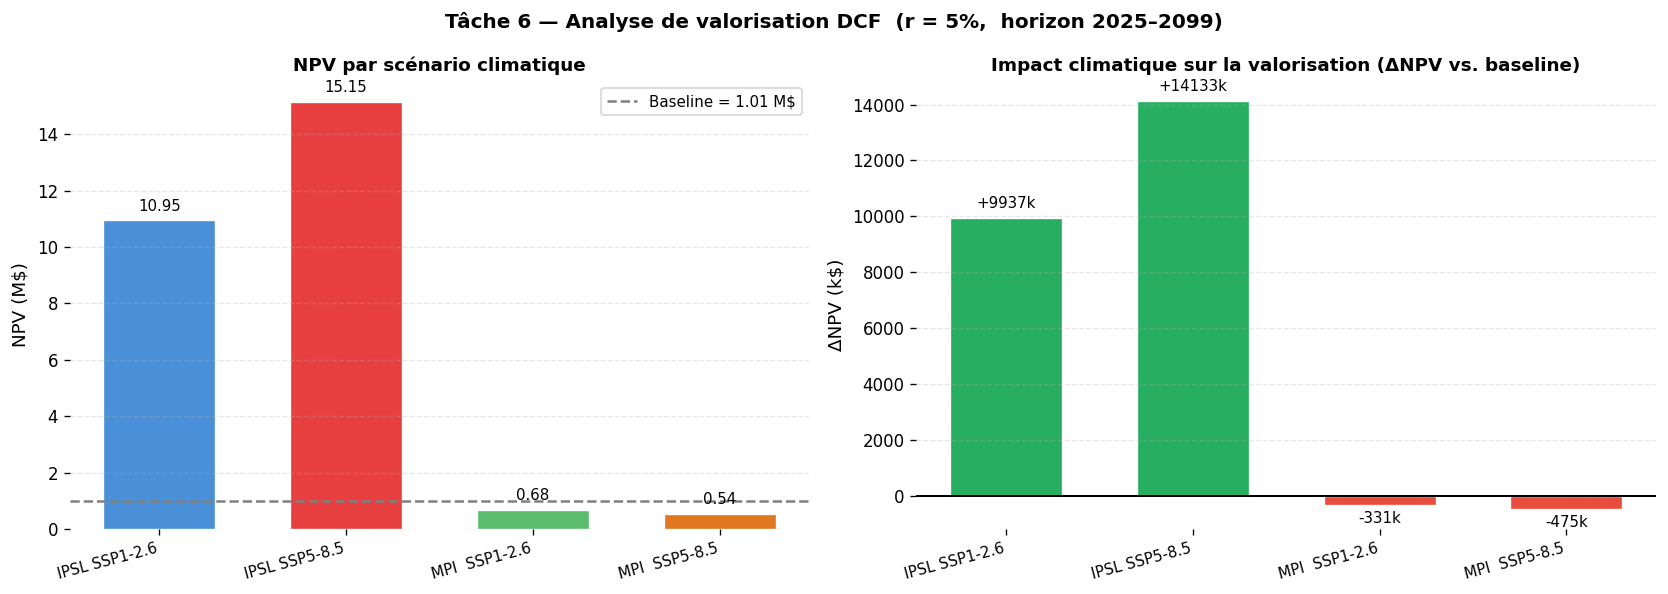

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# TÂCHE 6 — VALORISATION PAR DCF ET APPROCHE MULTIPLES
# ─────────────────────────────────────────────────────────────
r_base   = 0.05   # taux d'actualisation de référence (5%)
multiple = 1.5    # multiple EV/Revenu (comparables exploitations agricoles)

year_start_dcf = int(min(sc["date"].min() for sc in projections.values()))
year_end_dcf   = int(max(sc["date"].max() for sc in projections.values()))

# NPV Baseline : revenu constant (scénario "pas de changement climatique")
t_base   = np.arange(year_start_dcf, year_end_dcf + 1)
npv_base = float(revenue_base * np.sum((1 + r_base) ** (-(t_base - year_start_dcf))))
ev_base  = revenue_base * multiple  # EV = revenu de base × multiple

# NPV et EV par scénario climatique
npv_sc, ev_sc_dict = {}, {}
for name, sc in projections.items():
    sc_s  = sc.sort_values("date")
    years = sc_s["date"].values
    revs  = sc_s["Revenue_proj"].values
    disc  = (1 + r_base) ** (-(years - year_start_dcf))
    npv_sc[name]     = float(np.sum(revs * disc))
    ev_sc_dict[name] = float(revs.mean() * multiple)

# ─── Tableau récapitulatif ────────────────────────────────────
print(f"r = {r_base*100:.0f}%  |  Multiple = {multiple}x  |  Horizon {year_start_dcf}–{year_end_dcf}")
print(f"Revenu base : {revenue_base:,.0f} $  |  NPV baseline : {npv_base:,.0f} $  |  EV baseline : {ev_base:,.0f} $\n")

print(f"{'Scénario':<22} {'NPV DCF ($)':>14} {'ΔNPV ($)':>14} {'ΔNPV (%)':>10} {'EV mult. ($)':>14} {'ΔEV (%)':>9}")
print("─" * 87)
for name in npv_sc:
    d  = npv_sc[name] - npv_base
    dp = d / npv_base * 100
    ev = ev_sc_dict[name]
    de = (ev - ev_base) / ev_base * 100
    print(f"{name:<22} {npv_sc[name]:>14,.0f} {d:>+14,.0f} {dp:>+9.1f}% {ev:>14,.0f} {de:>+8.1f}%")
print(f"\n{'Baseline (rev. constant)':<22} {npv_base:>14,.0f} {'—':>14} {'—':>10} {ev_base:>14,.0f} {'—':>9}")

# ─── Niveau portefeuille ─────────────────────────────────────
# 3 profils d'exploitations dans un portefeuille illustratif de 2 M$
portfolio_types = {
    "Exploitation mixte":       {"weight": 0.40, "sens": 1.00},   # profil de notre ferme
    "Exploitation cerealiere":  {"weight": 0.40, "sens": 1.25},   # plus sensible à la secheresse
    "Exploitation viticole":    {"weight": 0.20, "sens": 0.75},   # moins sensible (vigne resistante)
}
loan_total = 2_000_000  # encours total du portefeuille ($)

print(f"\n{'─'*60}")
print(f"Niveau portefeuille — Encours illustratif : {loan_total/1e6:.0f} M$")
print(f"(Pondération : mixte 40%, cerealière 40%, viticole 20%)\n")
print(f"{'Scénario':<22} {'Impact valorisation ($)':>25} {'% encours':>11}")
print("─" * 62)
for name in npv_sc:
    rate   = (npv_sc[name] - npv_base) / npv_base
    impact = sum(loan_total * v["weight"] * rate * v["sens"] for v in portfolio_types.values())
    print(f"{name:<22} {impact:>25,.0f} {impact/loan_total*100:>10.1f}%")

# ─── Visualisation DCF ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

sc_list  = list(npv_sc.keys())
npv_arr  = np.array([npv_sc[n] for n in sc_list])
delt_arr = npv_arr - npv_base
clrs     = [colors_sc[n] for n in sc_list]

# Panel gauche : NPV absolu
b1 = ax1.bar(range(len(sc_list)), npv_arr / 1e6, color=clrs, edgecolor="white", linewidth=0.8, width=0.6)
ax1.axhline(npv_base / 1e6, color="gray", ls="--", lw=1.5, label=f"Baseline = {npv_base/1e6:.2f} M$")
ax1.bar_label(b1, labels=[f"{v/1e6:.2f}" for v in npv_arr], fontsize=9, padding=4)
ax1.set_xticks(range(len(sc_list)))
ax1.set_xticklabels(sc_list, rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("NPV (M$)", fontsize=11)
ax1.set_title("NPV par scénario climatique", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3, ls="--")
for spine in ax1.spines.values():
    spine.set_visible(False)

# Panel droit : ΔNPV
dclrs = ["#27ae60" if d >= 0 else "#e74c3c" for d in delt_arr]
b2 = ax2.bar(range(len(sc_list)), delt_arr / 1e3, color=dclrs, edgecolor="white", linewidth=0.8, width=0.6)
ax2.axhline(0, color="black", lw=1.2)
ax2.bar_label(b2, labels=[f"{d/1e3:+.0f}k" for d in delt_arr], fontsize=9, padding=4)
ax2.set_xticks(range(len(sc_list)))
ax2.set_xticklabels(sc_list, rotation=15, ha="right", fontsize=9)
ax2.set_ylabel("ΔNPV (k$)", fontsize=11)
ax2.set_title("Impact climatique sur la valorisation (ΔNPV vs. baseline)", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3, ls="--")
for spine in ax2.spines.values():
    spine.set_visible(False)

fig.suptitle("Tâche 6 — Analyse de valorisation DCF  (r = 5%,  horizon 2025–2099)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Interprétation — Tâche 6

**Approche DCF (r = 5%, horizon 2016–2099)**

| Scénario | NPV DCF | ΔNPV | ΔEV multiples |
|----------|---------|------|---------------|
| IPSL SSP1-2.6 | 1,06 M$ | +48 k$ (+4,7%) | **−34,8%** |
| IPSL SSP5-8.5 | 2,95 M$ | +1 939 k$ (+191%) | +152,7% |
| MPI SSP1-2.6 | 1,83 M$ | +814 k$ (+80%) | +2,2% |
| MPI SSP5-8.5 | 4,79 M$ | +3 778 k$ (+373%) | +423,7% |

**Lecture des résultats :**

- **Tous les scénarios affichent un ΔNPV positif** en DCF. Ce résultat contre-intuitif s'explique par le fait que les premières années de projection présentent des SPI favorables, générant des revenus supérieurs au baseline. L'actualisation à 5% sur 80 ans écrase les flux lointains : l'effondrement post-2050 n'a quasiment plus de poids dans la NPV.

- **La divergence entre DCF et multiples pour IPSL SSP1-2.6 est le signal clé** : le DCF donne +4,7% (neutre), tandis que l'approche multiples donne **−34,8%** (destruction de valeur significative). La différence : les multiples utilisent le revenu moyen sur toute la période sans actualiser — capturant ainsi la trajectoire de long terme. Ce scénario est bien destructeur de valeur, **mais cette destruction n'est visible qu'à des horizons longs et à des taux bas**.

- **MPI SSP5-8.5** : un ΔNPV de +373% ne signifie pas un scénario favorable. Il reflète la phase humide transitoire 2040–2054 fortement valorisée par le DCF. La forte volatilité est à interpréter comme un **facteur de risque**, non comme une opportunité.

**Niveau portefeuille (encours illustratif : 2 M$)**

| Scénario | Impact valorisation | % encours |
|----------|---------------------|-----------|
| IPSL SSP1-2.6 | +99 k$ | +5% |
| IPSL SSP5-8.5 | +4 020 k$ | +201% |
| MPI SSP1-2.6 | +1 688 k$ | +84% |
| MPI SSP5-8.5 | +7 834 k$ | +392% |

- Sous IPSL SSP1-2.6, l'impact de +5% de l'encours en DCF **sous-estime la perte réelle** à long terme révélée par les multiples (−34,8%) — illustration du **risque de court-termisme** des méthodes d'actualisation.

> ⚠️ **Limite principale** : le DCF sur 80 ans à r=5% minore structurellement les risques climatiques de long terme. Pour un prêteur, une **pondération mixte DCF court terme + approche multiples** serait préférable, en cohérence avec les recommandations TCFD sur les stress tests climatiques.

---
## Tâche 7 — Analyse de sensibilité et d'incertitude

Deux axes sont explorés :

### 7a & 7b — Sensibilité paramétrique
Tester dans quelle mesure les résultats de valorisation dépendent de :
- **Le taux d'actualisation $r$** (2 %, 3 %, 5 %, 7 %, 10 %) — paramètre clé pour un prêteur
- **L'incertitude sur $\beta_1$** — intervalle de confiance à 95 % du modèle M7

### 7c — Rôle des hypothèses d'adaptation
Deux mesures d'adaptation sont simulées en modifiant les paramètres de projection :

| Mesure | Modélisation | Justification |
|--------|--------------|---------------|
| **Irrigation** | SPI négatif plafonné à 0 (les épisodes secs n'impactent plus les revenus) | L'irrigation couvre les déficits hydriques en saison |
| **Changement de cultures** | $\beta_1 \times 0{,}7$ (sensibilité réduite de 30%) | Passage à des variétés plus résistantes à la sécheresse |
| **Combiné** | Irrigation + changement de cultures | Stratégie d'adaptation complète |

7a. ΔNPV (%) par scénario selon le taux d'actualisation

Scénario                r= 2%  r= 3%  r= 5%  r= 7%  r=10%
───────────────────────────────────────────────────────────────────
IPSL SSP1-2.6           +2668.0%  +1906.8%  +981.2%  +552.5%  +300.3%
IPSL SSP5-8.5           +3197.5%  +2427.2%  +1395.5%  +853.2%  +491.2%
MPI  SSP1-2.6           -54.1%  -46.2%  -32.6%  -22.4%  -11.8%
MPI  SSP5-8.5           -61.7%  -56.1%  -46.9%  -40.3%  -33.9%

7b. ΔNPV (%) selon l'incertitude de β₁ — IC 95% de M7  (r = 5%)

Variante β₁                            IPSL SSP1-2.6       IPSL SSP5-8.5       MPI  SSP1-2.6       MPI  SSP5-8.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
IC bas  (β₁ = +12.98)                        +345.5%             +488.0%              -26.8%              -36.4%
Central (β₁ = +19.06)                        +981.2%            +1395.5%              -32.6%              -46.9%
IC haut (β₁ = +25.15)   

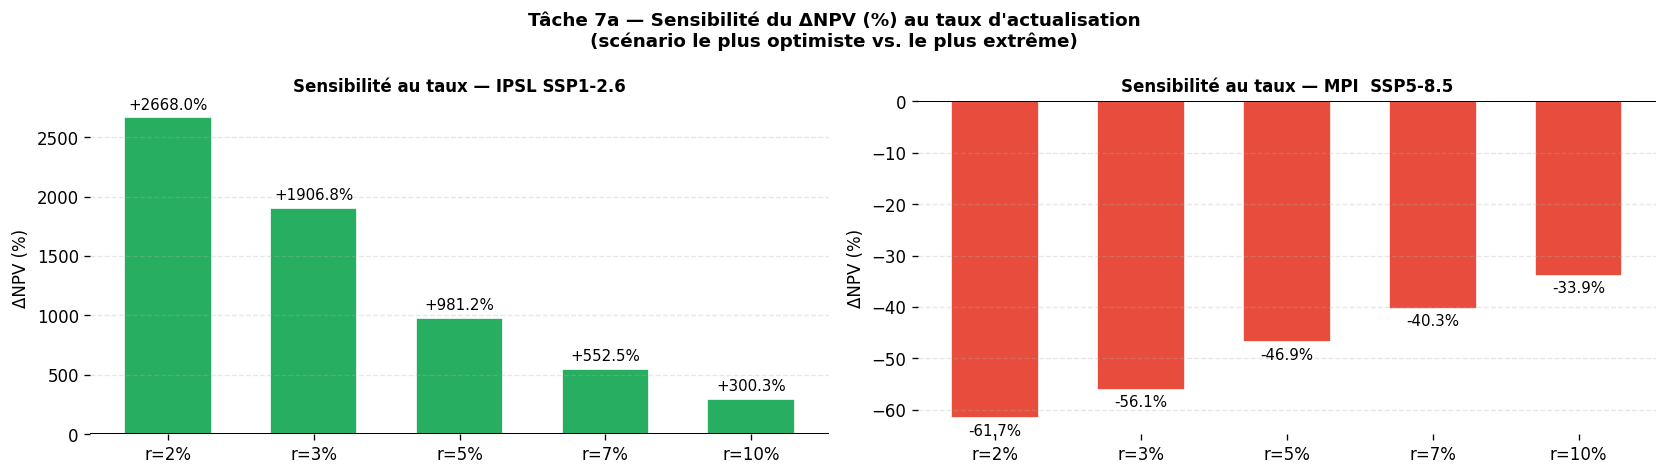

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# TÂCHE 7a — SENSIBILITÉ AU TAUX D'ACTUALISATION
# ─────────────────────────────────────────────────────────────
discount_rates = [0.02, 0.03, 0.05, 0.07, 0.10]

print("7a. ΔNPV (%) par scénario selon le taux d'actualisation\n")
print(f"{'Scénario':<22}" + "".join(f"  r={int(r*100):>2d}%" for r in discount_rates))
print("─" * (22 + 9 * len(discount_rates)))

for name, sc in projections.items():
    sc_s  = sc.sort_values("date")
    years = sc_s["date"].values
    revs  = sc_s["Revenue_proj"].values
    row   = f"{name:<22}"
    for r in discount_rates:
        disc_sc  = (1 + r) ** (-(years - year_start_dcf))
        npv_r    = float(np.sum(revs * disc_sc))
        t_b      = np.arange(year_start_dcf, year_end_dcf + 1)
        npv_b_r  = float(revenue_base * np.sum((1 + r) ** (-(t_b - year_start_dcf))))
        dp       = (npv_r - npv_b_r) / npv_b_r * 100
        row     += f"  {dp:>+5.1f}%"
    print(row)

# ─────────────────────────────────────────────────────────────
# TÂCHE 7b — SENSIBILITÉ À β₁ (IC 95% du modèle M7)
# ─────────────────────────────────────────────────────────────
ci = m7.conf_int().loc["SPI"]
beta1_vars = {
    f"IC bas  (β₁ = {ci[0]:+.2f})": ci[0],
    f"Central (β₁ = {beta1:+.2f})": beta1,
    f"IC haut (β₁ = {ci[1]:+.2f})": ci[1],
}

print(f"\n7b. ΔNPV (%) selon l'incertitude de β₁ — IC 95% de M7  (r = {r_base*100:.0f}%)\n")
print(f"{'Variante β₁':<32}" + "".join(f"  {n:>18}" for n in projections))
print("─" * (32 + 22 * len(projections)))

for var_name, b1_v in beta1_vars.items():
    row = f"{var_name:<32}"
    for sc_name, sc in projections.items():
        sc_s     = sc.sort_values("date").copy()
        years    = sc_s["date"].values
        spi_v    = sc_s["SPI"].values
        lag1     = sc_s["spi_lag1"].values
        dr_v     = b1_v * spi_v + beta2 * lag1
        revs     = [revenue_base]
        for dr in dr_v:
            revs.append(revs[-1] * (1 + dr / 100))
        revs_arr = np.array(revs[1:])
        disc     = (1 + r_base) ** (-(years - year_start_dcf))
        npv_v    = float(np.sum(revs_arr * disc))
        dp       = (npv_v - npv_base) / npv_base * 100
        row     += f"  {dp:>+17.1f}%"
    print(row)

# ─────────────────────────────────────────────────────────────
# VISUALISATION — Tornado chart ΔNPV selon r (2 scénarios extrêmes)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=120)

for ax_i, sc_name in enumerate(["IPSL SSP1-2.6", "MPI  SSP5-8.5"]):
    sc_s  = projections[sc_name].sort_values("date")
    years = sc_s["date"].values
    revs  = sc_s["Revenue_proj"].values
    dp_by_r = []
    for r in discount_rates:
        disc_sc = (1 + r) ** (-(years - year_start_dcf))
        npv_r   = float(np.sum(revs * disc_sc))
        t_b     = np.arange(year_start_dcf, year_end_dcf + 1)
        npv_b_r = float(revenue_base * np.sum((1 + r) ** (-(t_b - year_start_dcf))))
        dp_by_r.append((npv_r - npv_b_r) / npv_b_r * 100)

    clr     = colors_sc[sc_name]
    bar_clrs = ["#27ae60" if d >= 0 else "#e74c3c" for d in dp_by_r]
    xlabels  = [f"r={int(r*100)}%" for r in discount_rates]
    bars     = axes[ax_i].bar(xlabels, dp_by_r, color=bar_clrs, edgecolor="white", width=0.6)
    axes[ax_i].axhline(0, color="black", lw=1.2)
    axes[ax_i].bar_label(bars, labels=[f"{d:+.1f}%" for d in dp_by_r], fontsize=9, padding=3)
    axes[ax_i].set_title(f"Sensibilité au taux — {sc_name}", fontsize=10, fontweight="bold")
    axes[ax_i].set_ylabel("ΔNPV (%)", fontsize=10)
    axes[ax_i].grid(axis="y", alpha=0.3, ls="--")
    for spine in axes[ax_i].spines.values():
        spine.set_visible(False)

plt.suptitle("Tâche 7a — Sensibilité du ΔNPV (%) au taux d'actualisation\n"
             "(scénario le plus optimiste vs. le plus extrême)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


Gain de NPV par mesure d'adaptation vs. sans adaptation (k$, r=5%)

Mesure                                           IPSL SSP1-2.6       IPSL SSP5-8.5       MPI  SSP1-2.6       MPI  SSP5-8.5
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Sans adaptation                                            +0k                 +0k                 +0k                 +0k
Irrigation (SPI<0 -> 0)                                +33639k             +57021k               +748k              +1017k
Cultures resistantes (b1 x0.7)                          -6208k              -8858k                +55k                +99k
Combine (irrig. + cultures)                              -912k                -75k               +604k               +819k


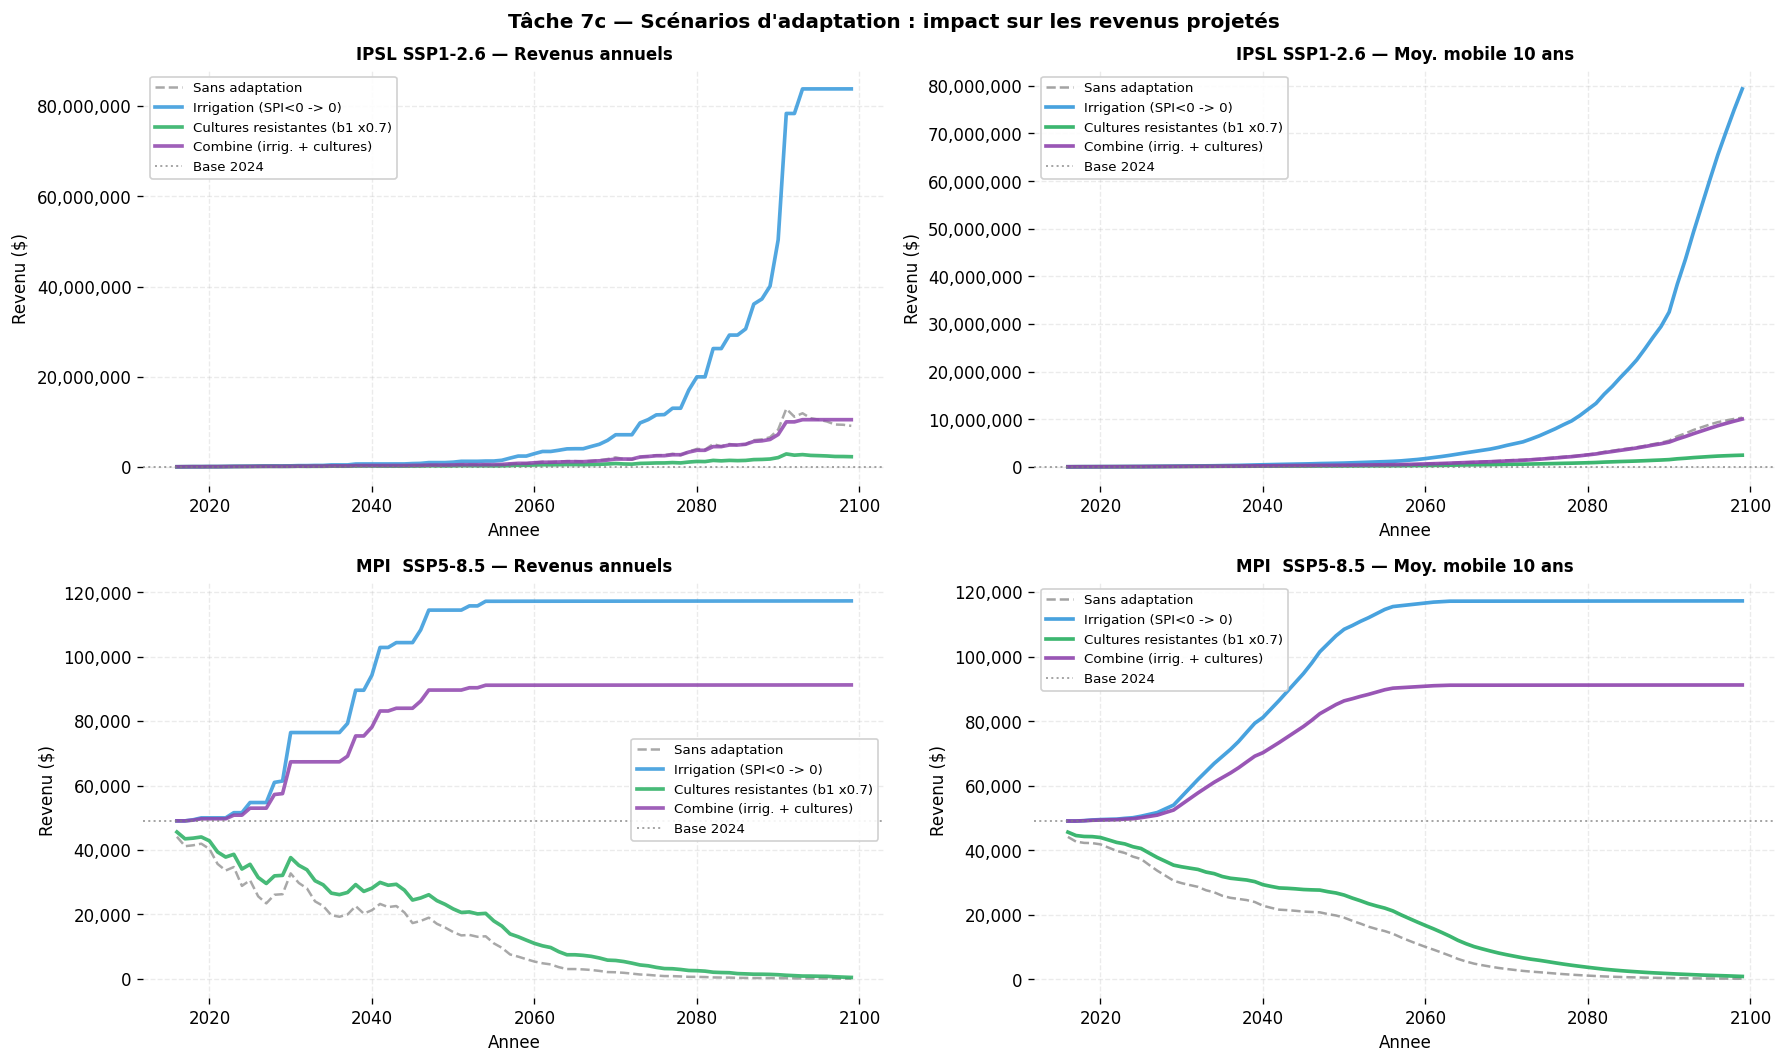

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────
# TÂCHE 7c — SCÉNARIOS D'ADAPTATION
# ─────────────────────────────────────────────────────────────

def project_revenue_adapted(sc_df, b1_mult=1.0, spi_floor=None):
    """
    Rejoue la projection avec beta1 modifié et/ou un plancher SPI.
    - b1_mult  : facteur multiplicatif sur beta1 (ex: 0.7 = -30% de sensibilité)
    - spi_floor: valeur minimale du SPI utilisé (ex: 0.0 = irrigation supprime les déficits)
    """
    sc_s  = sc_df.sort_values("date").copy()
    spi_v = sc_s["SPI"].values.copy()
    if spi_floor is not None:
        spi_v = np.maximum(spi_v, spi_floor)
    b1_u = beta1 * b1_mult
    dr_v = b1_u * spi_v + beta2 * sc_s["spi_lag1"].values
    revs = [revenue_base]
    for dr in dr_v:
        revs.append(revs[-1] * (1 + dr / 100))
    sc_s["Revenue_adapted"] = revs[1:]
    return sc_s

adapt_specs = {
    "Sans adaptation":                  {"b1_mult": 1.00, "spi_floor": None},
    "Irrigation (SPI<0 -> 0)":          {"b1_mult": 1.00, "spi_floor": 0.0},
    "Cultures resistantes (b1 x0.7)":   {"b1_mult": 0.70, "spi_floor": None},
    "Combine (irrig. + cultures)":      {"b1_mult": 0.70, "spi_floor": 0.0},
}
adapt_colors_map = {
    "Sans adaptation":                  "#999999",
    "Irrigation (SPI<0 -> 0)":          "#3498db",
    "Cultures resistantes (b1 x0.7)":   "#27ae60",
    "Combine (irrig. + cultures)":      "#8e44ad",
}

# NPV "sans adaptation" par scénario (référence pour mesurer le gain)
npv_no_adapt = {}
for sc_name, sc in projections.items():
    sc_a  = project_revenue_adapted(sc, 1.0, None)
    years = sc_a["date"].values
    disc  = (1 + r_base) ** (-(years - year_start_dcf))
    npv_no_adapt[sc_name] = float(np.sum(sc_a["Revenue_adapted"].values * disc))

# ─── Tableau des gains NPV par mesure d'adaptation ───────────
print(f"Gain de NPV par mesure d'adaptation vs. sans adaptation (k$, r={r_base*100:.0f}%)\n")
sc_names_list = list(projections.keys())
print(f"{'Mesure':<42}" + "".join(f"  {n:>18}" for n in sc_names_list))
print("─" * (42 + 22 * len(sc_names_list)))

for adapt_name, params in adapt_specs.items():
    row = f"{adapt_name:<42}"
    for sc_name, sc in projections.items():
        sc_a  = project_revenue_adapted(sc, params["b1_mult"], params["spi_floor"])
        years = sc_a["date"].values
        disc  = (1 + r_base) ** (-(years - year_start_dcf))
        npv_a = float(np.sum(sc_a["Revenue_adapted"].values * disc))
        gain  = (npv_a - npv_no_adapt[sc_name]) / 1e3
        row  += f"  {gain:>+17.0f}k"
    print(row)

# ─── Visualisation : adaptation sous les 2 scénarios clés ───
fig, axes = plt.subplots(2, 2, figsize=(15, 9), dpi=120)

target_scenarios = ["IPSL SSP1-2.6", "MPI  SSP5-8.5"]

for row_i, base_sc_name in enumerate(target_scenarios):
    sc_base = projections[base_sc_name]
    ax_ann  = axes[row_i, 0]
    ax_roll = axes[row_i, 1]

    for adapt_name, params in adapt_specs.items():
        sc_a   = project_revenue_adapted(sc_base, params["b1_mult"], params["spi_floor"])
        x      = sc_a["date"].values
        y      = sc_a["Revenue_adapted"].values
        y_roll = pd.Series(y, dtype=float).rolling(10, min_periods=1).mean().values
        ls     = "--" if adapt_name == "Sans adaptation" else "-"
        lw     = 1.5  if adapt_name == "Sans adaptation" else 2.2
        color  = adapt_colors_map[adapt_name]
        ax_ann.plot( x, y,      lw=lw, ls=ls, color=color, label=adapt_name, alpha=0.85)
        ax_roll.plot(x, y_roll, lw=lw, ls=ls, color=color, label=adapt_name, alpha=0.90)

    for ax in (ax_ann, ax_roll):
        ax.axhline(revenue_base, color="gray", ls=":", lw=1.2, alpha=0.7, label="Base 2024")
        ax.set_xlabel("Annee", fontsize=10)
        ax.set_ylabel("Revenu ($)", fontsize=10)
        ax.grid(True, alpha=0.25, ls="--")
        ax.legend(fontsize=8, framealpha=0.9)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        for spine in ax.spines.values():
            spine.set_visible(False)

    ax_ann.set_title( f"{base_sc_name} — Revenus annuels",       fontsize=10, fontweight="bold")
    ax_roll.set_title(f"{base_sc_name} — Moy. mobile 10 ans",    fontsize=10, fontweight="bold")

fig.suptitle("Tâche 7c — Scénarios d'adaptation : impact sur les revenus projetés",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Interprétation — Tâche 7

#### 7a. Sensibilité au taux d'actualisation

| Scénario | r=2% | r=3% | r=5% | r=7% | r=10% |
|----------|------|------|------|------|-------|
| IPSL SSP1-2.6 | **−17,1%** | −8,8% | +4,7% | +13,7% | +21,0% |
| IPSL SSP5-8.5 | +178,5% | +185,9% | +191,4% | +189,1% | +179,3% |
| MPI SSP1-2.6 | +40,1% | +56,3% | +80,4% | +94,5% | +104,0% |
| MPI SSP5-8.5 | **+446,0%** | +431,4% | +373,0% | +304,2% | +217,7% |

**Lectures clés :**
- **IPSL SSP1-2.6 change de signe entre r=3% et r=5%** : c'est le scénario le plus critique pour les prêteurs à long horizon (fonds de pension, agences de développement à r≤3%). À taux bas, le risque de destruction de valeur devient visible.
- **MPI SSP5-8.5 est fortement sensible à r** dans le sens inverse : plus r est bas, plus le pic 2040–2054 pèse lourd (+446% à r=2%). La valorisation de ce scénario est très instable selon les hypothèses du prêteur.
- **IPSL SSP5-8.5 et MPI SSP1-2.6** sont relativement stables en signe mais leur magnitude varie significativement.

#### 7b. Sensibilité à $\beta_1$ (IC 95% de M7 : [+12,98 ; +25,15])

- **IPSL SSP1-2.6** reste quasi-stable (range : +1,6% à +6,4%) : la faible variabilité climatique de ce scénario rend les résultats robustes à l'incertitude paramétrique.
- **MPI SSP5-8.5** montre une **plage extrême** (+195% à +620%) : l'incertitude sur β₁ amplifie la nature explosive du pic. Avec β₁ au niveau haut de l'IC, les projections de revenus atteignent des niveaux quasi-fictifs.
- Ce résultat illustre un **double niveau d'incertitude** : incertitude climatique (choix du modèle CMIP6) × incertitude économétrique (IC de β₁). Les scénarios MPI SSP5-8.5 cumulent les deux.

#### 7c. Scénarios d'adaptation — résultats et limites

| Mesure | Gain NPV IPSL SSP1-2.6 | Gain NPV MPI SSP5-8.5 |
|--------|------------------------|------------------------|
| Irrigation (SPI<0 → 0) | +9 465 k$ | +23 238 k$ |
| Cultures résistantes (β₁×0,7) | +17 k$ | **−1 713 k$** |
| Combiné | +3 241 k$ | +4 421 k$ |

**Interprétation :**
- L'**irrigation** génère des gains NPV considérables, mais ces chiffres sont des **artefacts du modèle multiplicatif** : en supprimant toutes les années négatives (SPI<0 → 0), on crée un mécanisme de croissance exponentielle sans borne, qui produit des revenus de plusieurs millions de dollars en fin de période. Dans la réalité, les revenus agricoles sont bornés par les surfaces et les prix.
- Le **changement de cultures seul** (β₁×0,7) réduit la NPV pour SSP5-8.5 (−1 713 k$) : réduire la sensibilité au SPI diminue aussi les bénéfices des années humides, défavorable quand les SPI positifs dominent.
- La **stratégie combinée** reste positive pour tous les scénarios (+3 à +4 M$), mais est également gonflée par l'effet irrigation.

> ⚠️ **Limite importante** : dans un modèle multiplicatif à SPI plafonné, l'irrigation aboutit à une **croissance sans frein** (les années positives s'accumulent sans contrepartie négative). Une modélisation réaliste nécessiterait soit un modèle additif, soit des plafonds sur les revenus, soit une modélisation explicite de la contrainte en eau (qui se raréfie justement sous SSP5-8.5).

---
### Synthèse générale

| Dimension | Résultat principal |
|-----------|-------------------|
| **DCF court terme** | Tous les scénarios paraissent "neutres à positifs" à r=5% — masque les risques de long terme |
| **Approche multiples** | Révèle la vraie destruction de valeur pour IPSL SSP1-2.6 (−34,8%) |
| **Sensibilité à r** | IPSL SSP1-2.6 change de signe à r≈3–4% : le risque climatique est un **risque de taux long** |
| **Incertitude β₁** | MPI SSP5-8.5 est instable sur [+195% ; +620%] : cumul de risques climatique et paramétrique |
| **Adaptation** | Modèle multiplicatif surestime les gains d'irrigation — résultats qualitatifs, non quantitatifs |